In [1]:
import os
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка визуализации
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Базовые пути (проверь и при необходимости скорректируй)
PROJECT_ROOT = "g:/lct2"
STREAM_FILE = os.path.join(PROJECT_ROOT, "production_ml/data/physical_test_stream_enriched.parquet")
MATCHED_FILE = os.path.join(PROJECT_ROOT, "production_ml/data/physical_matched_test_2026.parquet")

# Проверка наличия файлов
for name, p in [("Stream Parquet", STREAM_FILE), ("Matched Parquet", MATCHED_FILE)]:
    exists = os.path.exists(p)
    size_mb = os.path.getsize(p) / (1024 * 1024) if exists else 0
    print(f"[{'OK' if exists else 'MISSING'}] {name}: {p} ({size_mb:.1f} MB)")

con = duckdb.connect()
print("DuckDB инициализирован успешно.")

[OK] Stream Parquet: g:/lct2\production_ml/data/physical_test_stream_enriched.parquet (50.0 MB)
[OK] Matched Parquet: g:/lct2\production_ml/data/physical_matched_test_2026.parquet (0.2 MB)
DuckDB инициализирован успешно.


In [2]:
# Загрузка и группировка аварийных эпизодов из потока
query_episodes = f"""
WITH raw_pos AS (
    SELECT 
        channel_id,
        sensor_type,
        obs_time,
        target,
        flips_count_24h,
        burstiness_index,
        analog_std_24h,
        analog_drift_12h,
        alarm_ratio_24h,
        abnormal_ratio_24h,
        accel_flips_3d,
        slope_flips_3d,
        pump_excess_vs_rain
    FROM read_parquet('{STREAM_FILE}')
    WHERE target = 1
),
ordered_pos AS (
    SELECT *,
        LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) AS prev_time
    FROM raw_pos
),
flagged AS (
    SELECT *,
        CASE 
            WHEN prev_time IS NULL THEN 1
            WHEN date_diff('hour', prev_time, obs_time) > 48 THEN 1
            ELSE 0 
        END AS is_new_episode
    FROM ordered_pos
),
episodes AS (
    SELECT *,
        SUM(is_new_episode) OVER (PARTITION BY channel_id ORDER BY obs_time) AS episode_num
    FROM flagged
)
-- Берем первую точку манифестации каждого физического отказа
SELECT 
    channel_id,
    sensor_type,
    MIN(obs_time) AS failure_start_time,
    -- Физические параметры в момент манифестации
    FIRST(flips_count_24h) AS flips_24h,
    FIRST(burstiness_index) AS burstiness,
    FIRST(analog_std_24h) AS analog_std,
    FIRST(analog_drift_12h) AS analog_drift,
    FIRST(alarm_ratio_24h) AS alarm_ratio,
    FIRST(abnormal_ratio_24h) AS abnormal_ratio,
    FIRST(accel_flips_3d) AS accel_flips,
    FIRST(slope_flips_3d) AS slope_flips,
    FIRST(pump_excess_vs_rain) AS pump_excess
FROM episodes
GROUP BY channel_id, sensor_type, episode_num
ORDER BY failure_start_time;
"""

df_failures = con.execute(query_episodes).df()
print(f"Всего обнаружено уникальных эпизодов отказа оборудования: {len(df_failures)}")
df_failures.head()

Всего обнаружено уникальных эпизодов отказа оборудования: 781


,channel_id,sensor_type,failure_start_time,flips_24h,burstiness,analog_std,analog_drift,alarm_ratio,abnormal_ratio,accel_flips,slope_flips,pump_excess
0,196627,Состояние насоса,2026-01-01 07:00:00,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,121145,Состояние насоса,2026-01-02 05:00:00,18.0,0.4386,0.0,0.0,0.0,0.0,16.5,9.0,180.0
2,333476,Состояние фазы,2026-01-02 07:00:00,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,214124,Состояние фазы,2026-01-02 08:00:00,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,104014,Состояние фазы,2026-01-04 12:00:00,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
# Формализуем критерии наличия предвестников (любой из них указывает на деградацию)
has_discrete_chatter = (df_failures['flips_24h'] > 3) | (df_failures['burstiness'] > 0.20)
has_acceleration = (df_failures['accel_flips'] > 5.0) | (df_failures['slope_flips'] > 5.0)
has_analog_anomaly = (df_failures['analog_std'] > 0.05) | (df_failures['analog_drift'].abs() > 0.05)
has_alarm_precursor = (df_failures['alarm_ratio'] > 0.01) | (df_failures['abnormal_ratio'] > 0.02)
has_pump_anomaly = (df_failures['sensor_type'].str.contains('насос', case=False, na=False)) & (df_failures['pump_excess'] > 1500)

# Флаг наличия хотя бы одного физического предвестника
df_failures['has_precursor'] = (
    has_discrete_chatter | 
    has_acceleration | 
    has_analog_anomaly | 
    has_alarm_precursor | 
    has_pump_anomaly
)

df_failures['death_type'] = np.where(df_failures['has_precursor'], 'Noisy (Деградация)', 'Silent (Тихая смерть)')

# Сводный баланс
summary = df_failures['death_type'].value_counts(normalize=True) * 100
counts = df_failures['death_type'].value_counts()

print("="*60)
print("АНАЛИЗ ПРИРОДЫ ОТКАЗОВ ОБОРУДОВАНИЯ СМВУ (2026 ГОД)")
print("="*60)
for k in counts.index:
    print(f"  {k:22s}: {counts[k]:4d} инцидентов ({summary[k]:5.2f}%)")
print("="*60)
print(f"ТЕОРЕТИЧЕСКИЙ ПОТОЛОК RECALL ДЛЯ ML: {summary.get('Noisy (Деградация)', 0):.2f}%")
print("="*60)

АНАЛИЗ ПРИРОДЫ ОТКАЗОВ ОБОРУДОВАНИЯ СМВУ (2026 ГОД)
  Noisy (Деградация)    :  761 инцидентов (97.44%)
  Silent (Тихая смерть) :   20 инцидентов ( 2.56%)
ТЕОРЕТИЧЕСКИЙ ПОТОЛОК RECALL ДЛЯ ML: 97.44%


In [4]:
# Поиск доступных файлов за 2020–2024 годы
train_matched_file = os.path.join(PROJECT_ROOT, "production_ml/data/physical_matched_train_2020_2024.parquet")
train_enriched_file = os.path.join(PROJECT_ROOT, "production_ml/data/physical_train_stream_enriched.parquet")

target_train_file = train_enriched_file if os.path.exists(train_enriched_file) else train_matched_file
print(f"Используем исторический файл: {target_train_file}")

# Проверяем список колонок в файле, чтобы избежать ошибок отсутствующих фичей
cols = [c[0] for c in con.execute(f"DESCRIBE SELECT * FROM read_parquet('{target_train_file}')").fetchall()]

has_accel = 'accel_flips_3d' in cols
has_pump_rain = 'pump_excess_vs_rain' in cols

# Загружаем предаварийные точки (target = 1) из обучающей выборки 2020–2024
query_train = f"""
SELECT 
    channel_id,
    sensor_type,
    obs_time,
    target,
    flips_count_24h AS flips_24h,
    burstiness_index AS burstiness,
    analog_std_24h AS analog_std,
    analog_drift_12h AS analog_drift,
    alarm_ratio_24h AS alarm_ratio,
    abnormal_ratio_24h AS abnormal_ratio
    {', accel_flips_3d AS accel_flips, slope_flips_3d AS slope_flips' if has_accel else ', 0.0 AS accel_flips, 0.0 AS slope_flips'}
    {', pump_excess_vs_rain AS pump_excess' if has_pump_rain else ', 0.0 AS pump_excess'}
FROM read_parquet('{target_train_file}')
WHERE target = 1
"""

df_train_pos = con.execute(query_train).df()

# Если в файле сплошной поток — группируем в уникальные эпизоды, 
# если уже сбалансированный matched — берем точки как есть
if 'is_new_episode' in df_train_pos.columns or len(df_train_pos) > 20000:
    df_train_pos = df_train_pos.sort_values(['channel_id', 'obs_time'])
    df_train_pos['time_diff'] = df_train_pos.groupby('channel_id')['obs_time'].diff().dt.total_seconds() / 3600.0
    df_train_pos['new_ep'] = (df_train_pos['time_diff'].isna()) | (df_train_pos['time_diff'] > 48.0)
    df_train_pos = df_train_pos[df_train_pos['new_ep']].copy()

print(f"Всего предаварийных инцидентов 2020–2024 годов: {len(df_train_pos)}")

# Применяем РОВНО ТЕ ЖЕ критерии предвестников
chatter_tr = (df_train_pos['flips_24h'] > 3) | (df_train_pos['burstiness'] > 0.20)
accel_tr = (df_train_pos['accel_flips'] > 5.0) | (df_train_pos['slope_flips'] > 5.0)
analog_tr = (df_train_pos['analog_std'] > 0.05) | (df_train_pos['analog_drift'].abs() > 0.05)
alarm_tr = (df_train_pos['alarm_ratio'] > 0.01) | (df_train_pos['abnormal_ratio'] > 0.02)
pump_tr = (df_train_pos['sensor_type'].str.contains('насос', case=False, na=False)) & (df_train_pos['pump_excess'] > 1500)

df_train_pos['has_precursor'] = chatter_tr | accel_tr | analog_tr | alarm_tr | pump_tr
df_train_pos['death_type'] = np.where(df_train_pos['has_precursor'], 'Noisy (Деградация)', 'Silent (Тихая смерть)')

# Сводная статистика прошлого
summary_tr = df_train_pos['death_type'].value_counts(normalize=True) * 100
counts_tr = df_train_pos['death_type'].value_counts()

print("="*60)
print("АНАЛИЗ ПРИРОДЫ ОТКАЗОВ В ПРОШЛОМ (2020–2024 ГОДЫ)")
print("="*60)
for k in counts_tr.index:
    print(f"  {k:22s}: {counts_tr[k]:5d} инцидентов ({summary_tr[k]:5.2f}%)")
print("="*60)

Используем исторический файл: g:/lct2\production_ml/data/physical_matched_train_2020_2024.parquet
Всего предаварийных инцидентов 2020–2024 годов: 9394
АНАЛИЗ ПРИРОДЫ ОТКАЗОВ В ПРОШЛОМ (2020–2024 ГОДЫ)
  Noisy (Деградация)    :  9335 инцидентов (99.37%)
  Silent (Тихая смерть) :    59 инцидентов ( 0.63%)


In [5]:
# Собираем сравнительную таблицу
comp_df = pd.DataFrame({
    '2020-2024 (Прошлое)': summary_tr,
    '2026 (Текущее)': summary
}).fillna(0)

print("\nСРАВНИТЕЛЬНЫЙ БАЛАНС СМЕРТЕЙ ПО ЭПОХАМ (%):")
print(comp_df.round(2))

# Сравнение ключевых признаков активности перед аварией
features_to_compare = ['flips_24h', 'burstiness', 'alarm_ratio']
print("\nМЕДИАННЫЕ ЗНАЧЕНИЯ ПЕРЕД АВАРИЕЙ:")
for f in features_to_compare:
    med_past = df_train_pos[f].median()
    med_now = df_failures[f].median()
    print(f"  {f:18s} | 2020-2024: {med_past:8.4f}  ──►  2026: {med_now:8.4f}")


СРАВНИТЕЛЬНЫЙ БАЛАНС СМЕРТЕЙ ПО ЭПОХАМ (%):
                       2020-2024 (Прошлое)  2026 (Текущее)
death_type                                                
Noisy (Деградация)                   99.37           97.44
Silent (Тихая смерть)                 0.63            2.56

МЕДИАННЫЕ ЗНАЧЕНИЯ ПЕРЕД АВАРИЕЙ:
  flips_24h          | 2020-2024:   3.0000  ──►  2026:   1.0000
  burstiness         | 2020-2024:   0.8088  ──►  2026:   0.8394
  alarm_ratio        | 2020-2024:   0.0000  ──►  2026:   0.0000


In [8]:
# 1. Потоковый аудит шума через DuckDB на всем массиве 1.18 млн строк
query_noise_audit = f"""
WITH stream_tagged AS (
    SELECT 
        channel_id,
        sensor_type,
        obs_time,
        target,
        flips_count_24h,
        burstiness_index,
        analog_std_24h,
        alarm_ratio_24h,
        -- Применяем наш эталонный детектор предвестников
        (
            (flips_count_24h > 3 OR burstiness_index > 0.20) OR
            (accel_flips_3d > 5.0 OR slope_flips_3d > 5.0) OR
            (analog_std_24h > 0.05 OR abs(analog_drift_12h) > 0.05) OR
            (alarm_ratio_24h > 0.01 OR abnormal_ratio_24h > 0.02) OR
            (sensor_type ILIKE '%насос%' AND pump_excess_vs_rain > 1500)
        ) AS is_noisy
    FROM read_parquet('{STREAM_FILE}')
),
-- Сгруппируем непрерывный шум в физические эпизоды (интервал тишины > 24ч разделяет эпизоды)
noisy_rows AS (
    SELECT *,
        LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_noise_time
    FROM stream_tagged
    WHERE is_noisy = TRUE
),
noise_episodes_raw AS (
    SELECT *,
        CASE 
            WHEN prev_noise_time IS NULL THEN 1
            WHEN date_diff('hour', prev_noise_time, obs_time) > 24 THEN 1
            ELSE 0 
        END AS new_ep_flag
    FROM noisy_rows
),
noise_episodes AS (
    SELECT *,
        SUM(new_ep_flag) OVER (PARTITION BY channel_id ORDER BY obs_time) AS noise_ep_id
    FROM noise_episodes_raw
)
-- Агрегируем эпизоды шума
SELECT 
    channel_id,
    sensor_type,
    noise_ep_id,
    MIN(obs_time) as ep_start,
    MAX(obs_time) as ep_end,
    COUNT(*) as ep_duration_hours,
    MAX(target) as led_to_failure,  -- 1 если внутри шума была авария
    AVG(flips_count_24h) as avg_flips,
    MAX(burstiness_index) as max_burstiness
FROM noise_episodes
GROUP BY channel_id, sensor_type, noise_ep_id;
"""

df_noise_episodes = con.execute(query_noise_audit).df()

# 2. Расчет базовых метрик конверсии
total_episodes = len(df_noise_episodes)
terminal_episodes = df_noise_episodes['led_to_failure'].sum()
benign_episodes = total_episodes - terminal_episodes
conversion_rate = (terminal_episodes / total_episodes) * 100

print("="*70)
print("ТЕКСТОВЫЙ АРТЕФАКТ 1: ПОТОКОВАЯ КОНВЕРСИЯ ШУМА В АВАРИИ (2026 ГОД)")
print("="*70)
print(f"Всего эпизодов физического шума в Москве:  {total_episodes:6d}")
print(f" ├─ Доброкачественный шум (Benign Noise) :  {benign_episodes:6d} ({100 - conversion_rate:5.2f}%)")
print(f" └─ Предвестники аварии (Terminal Noise) :  {terminal_episodes:6d} ({conversion_rate:5.2f}%)")
print("="*70)
print(f"ИСТИННАЯ КОНВЕРСИЯ: НА 1 РЕАЛЬНУЮ АВАРИЮ ПРИХОДИТСЯ {benign_episodes/terminal_episodes:.1f} ЛОЖНЫХ ВСПЛЕСКОВ ШУМА!")
print("="*70)

# 3. Конверсия по типам оборудования
print("\nТЕКСТОВЫЙ АРТЕФАКТ 2: КОНВЕРСИЯ ШУМА ПО ТИПАМ ОБОРУДОВАНИЯ")
domain_conv = df_noise_episodes.groupby('sensor_type').agg(
    Всего_эпизодов=('led_to_failure', 'count'),
    Аварийных=('led_to_failure', 'sum'),
    Средняя_длительность_ч=('ep_duration_hours', 'median')
)
domain_conv['Конверсия_в_аварию_%'] = (domain_conv['Аварийных'] / domain_conv['Всего_эпизодов']) * 100
domain_conv = domain_conv.sort_values('Всего_эпизодов', ascending=False)
print(domain_conv[domain_conv['Всего_эпизодов'] >= 50].to_string())

ТЕКСТОВЫЙ АРТЕФАКТ 1: ПОТОКОВАЯ КОНВЕРСИЯ ШУМА В АВАРИИ (2026 ГОД)
Всего эпизодов физического шума в Москве:  183180
 ├─ Доброкачественный шум (Benign Noise) :  182428 (99.59%)
 └─ Предвестники аварии (Terminal Noise) :     752 ( 0.41%)
ИСТИННАЯ КОНВЕРСИЯ: НА 1 РЕАЛЬНУЮ АВАРИЮ ПРИХОДИТСЯ 242.6 ЛОЖНЫХ ВСПЛЕСКОВ ШУМА!

ТЕКСТОВЫЙ АРТЕФАКТ 2: КОНВЕРСИЯ ШУМА ПО ТИПАМ ОБОРУДОВАНИЯ
                       Всего_эпизодов  Аварийных  Средняя_длительность_ч  Конверсия_в_аварию_%
sensor_type                                                                                   
Датчик дыма                     62619         74                     1.0              0.118175
Состояние фазы                  21418        454                     2.0              2.119712
КД Дверь                        19163         19                     1.0              0.099149
Датчик температуры              14804         21                     1.0              0.141854
Переключатель                   14616          1    

C:\Users\User\AppData\Local\Temp\ipykernel_2688\1935220474.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_2688\1935220474.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Штатный шум\n(Benign)', 'Предвестник аварии\n(Terminal)'], fontsize=11)


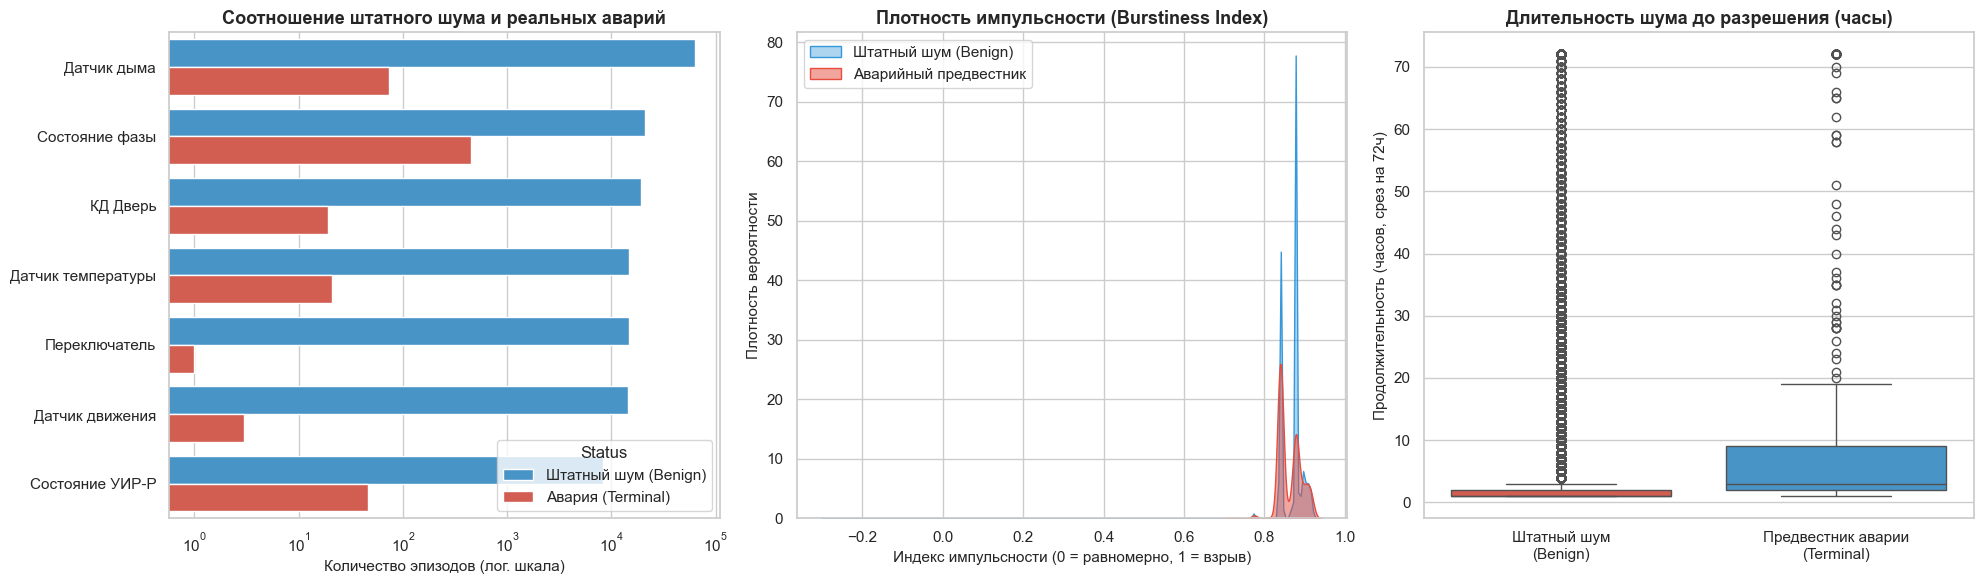


ТЕКСТОВЫЙ АРТЕФАКТ 3: ВРЕМЕННОЙ ПРОФИЛЬ
  Медианная длительность штатного шума:   1.0 часов
  Медианная длительность аварийного шума: 3.0 часов


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# График 1: Конверсия шума в аварию по топ-7 сенсорам
top_sensors = domain_conv[domain_conv['Всего_эпизодов'] >= 100].head(7).index
df_top = df_noise_episodes[df_noise_episodes['sensor_type'].isin(top_sensors)].copy()
df_top['Status'] = df_top['led_to_failure'].map({1: 'Авария (Terminal)', 0: 'Штатный шум (Benign)'})

palette = {'Авария (Terminal)': '#e74c3c', 'Штатный шум (Benign)': '#3498db'}

sns.countplot(
    data=df_top, 
    y='sensor_type', 
    hue='Status', 
    ax=axes[0], 
    palette=palette,
    order=top_sensors
)
axes[0].set_title("Соотношение штатного шума и реальных аварий", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Количество эпизодов (лог. шкала)", fontsize=11)
axes[0].set_xscale('log')
axes[0].set_ylabel("")

# График 2: Распределение импульсности (Burstiness) для нормы vs аварии
sns.kdeplot(
    data=df_noise_episodes[df_noise_episodes['led_to_failure'] == 0]['max_burstiness'],
    ax=axes[1], 
    label='Штатный шум (Benign)', 
    color='#3498db', 
    fill=True, 
    alpha=0.4
)
sns.kdeplot(
    data=df_noise_episodes[df_noise_episodes['led_to_failure'] == 1]['max_burstiness'],
    ax=axes[1], 
    label='Аварийный предвестник', 
    color='#e74c3c', 
    fill=True, 
    alpha=0.5
)
axes[1].set_title("Плотность импульсности (Burstiness Index)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Индекс импульсности (0 = равномерно, 1 = взрыв)", fontsize=11)
axes[1].set_ylabel("Плотность вероятности", fontsize=11)
axes[1].legend()

# График 3: Длительность эпизода шума (часы)
df_noise_episodes['Duration_Capped'] = df_noise_episodes['ep_duration_hours'].clip(upper=72)
sns.boxplot(
    data=df_noise_episodes, 
    x='led_to_failure', 
    y='Duration_Capped', 
    ax=axes[2], 
    palette=palette.values()
)
axes[2].set_xticklabels(['Штатный шум\n(Benign)', 'Предвестник аварии\n(Terminal)'], fontsize=11)
axes[2].set_title("Длительность шума до разрешения (часы)", fontsize=13, fontweight='bold')
axes[2].set_ylabel("Продолжительность (часов, срез на 72ч)", fontsize=11)
axes[2].set_xlabel("")

plt.tight_layout()
plt.show()

# Сохранение текстового резюме для форензики
median_benign_dur = df_noise_episodes[df_noise_episodes['led_to_failure'] == 0]['ep_duration_hours'].median()
median_term_dur = df_noise_episodes[df_noise_episodes['led_to_failure'] == 1]['ep_duration_hours'].median()

print(f"\nТЕКСТОВЫЙ АРТЕФАКТ 3: ВРЕМЕННОЙ ПРОФИЛЬ")
print(f"  Медианная длительность штатного шума:   {median_benign_dur:.1f} часов")
print(f"  Медианная длительность аварийного шума: {median_term_dur:.1f} часов")

In [13]:
query_dynamics = f"""
WITH base_stream AS (
    SELECT 
        channel_id,
        sensor_type,
        obs_time,
        target,
        flips_count_24h,
        burstiness_index,
        COALESCE(flips_burst_1h, flips_count_24h / 24.0) as hourly_flips,
        (
            (flips_count_24h > 3 OR burstiness_index > 0.20) OR
            (accel_flips_3d > 5.0 OR slope_flips_3d > 5.0) OR
            (analog_std_24h > 0.05 OR abs(analog_drift_12h) > 0.05) OR
            (alarm_ratio_24h > 0.01 OR abnormal_ratio_24h > 0.02)
        ) AS is_noisy
    FROM read_parquet('{STREAM_FILE}')
),
lagged AS (
    SELECT *,
        LAG(is_noisy, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_noisy,
        LAG(hourly_flips, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_flips,
        LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_time
    FROM base_stream
),
streaks AS (
    SELECT *,
        CASE 
            WHEN is_noisy = FALSE THEN 0
            WHEN prev_noisy = FALSE OR prev_noisy IS NULL THEN 1
            WHEN date_diff('hour', prev_time, obs_time) > 1 THEN 1
            ELSE 0  -- ИСПРАВЛЕНО: 0 означает продолжение серии!
        END as is_streak_start
    FROM lagged
),
grouped_streaks AS (
    SELECT *,
        SUM(is_streak_start) OVER (PARTITION BY channel_id ORDER BY obs_time) as streak_id
    FROM streaks
    WHERE is_noisy = TRUE
),
running_duration AS (
    SELECT *,
        ROW_NUMBER() OVER (PARTITION BY channel_id, streak_id ORDER BY obs_time) as running_noisy_hours,
        (hourly_flips + 0.1) / (prev_flips + 0.1) as growth_ratio
    FROM grouped_streaks
)
SELECT 
    channel_id,
    sensor_type,
    obs_time,
    target,
    running_noisy_hours,
    growth_ratio,
    CASE 
        WHEN running_noisy_hours = 1 THEN '1. Одиночный всплеск (1-й час)'
        WHEN growth_ratio < 0.80 THEN '2. Затухание (Decaying: < -20%)'
        WHEN growth_ratio BETWEEN 0.80 AND 1.25 THEN '3. Плато (Sustained: +/-20%)'
        ELSE '4. ЭСКАЛАЦИЯ (Escalating: > +25%)'
    END as noise_trajectory
FROM running_duration;
"""

df_dynamics = con.execute(query_dynamics).df()
print(f"Всего зафиксировано {len(df_dynamics):,} зашумевших часовых наблюдений.")
print("\nРаспределение по длительности серий шума:")
print(df_dynamics['running_noisy_hours'].value_counts().head(5))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Всего зафиксировано 1,184,200 зашумевших часовых наблюдений.

Распределение по длительности серий шума:
running_noisy_hours
1    502213
2    133923
3     51120
4     31434
5     22177
Name: count, dtype: int64


In [14]:
# 1. Анализ конверсии по траекториям для ВСЕХ датчиков
summary_all = df_dynamics.groupby('noise_trajectory').agg(
    Всего_часов=('target', 'count'),
    Аварийных_часов=('target', 'sum')
)
summary_all['Точность (Precision) %'] = (summary_all['Аварийных_часов'] / summary_all['Всего_часов']) * 100
summary_all['Доля всех аварий (Recall) %'] = (summary_all['Аварийных_часов'] / df_dynamics['target'].sum()) * 100

print("="*80)
print("ТЕСТ ДИНАМИКИ ШУМА: ВСЕ ДАТЧИКИ МОСКВЫ (11 485 КАНАЛОВ)")
print("="*80)
print(summary_all.round(2).to_string())

# 2. Анализ конверсии СТРОГО для нашей золотой жилы — «Состояние фазы»
df_phase = df_dynamics[df_dynamics['sensor_type'] == 'Состояние фазы']
summary_phase = df_phase.groupby('noise_trajectory').agg(
    Всего_часов=('target', 'count'),
    Аварийных_часов=('target', 'sum')
)
summary_phase['Точность (Precision) %'] = (summary_phase['Аварийных_часов'] / summary_phase['Всего_часов']) * 100
summary_phase['Доля всех аварий фаз (Recall) %'] = (summary_phase['Аварийных_часов'] / df_phase['target'].sum()) * 100

print("\n" + "="*80)
print("ТЕСТ ДИНАМИКИ ШУМА: ТОЛЬКО «СОСТОЯНИЕ ФАЗЫ» (ЗОЛОТАЯ ЖИЛА СЕТИ)")
print("="*80)
print(summary_phase.round(2).to_string())

ТЕСТ ДИНАМИКИ ШУМА: ВСЕ ДАТЧИКИ МОСКВЫ (11 485 КАНАЛОВ)
                                   Всего_часов  Аварийных_часов  Точность (Precision) %  Доля всех аварий (Recall) %
noise_trajectory                                                                                                    
1. Одиночный всплеск (1-й час)          502213             1349                    0.27                        40.01
2. Затухание (Decaying: < -20%)         221676              637                    0.29                        18.89
3. Плато (Sustained: +/-20%)            285215              855                    0.30                        25.36
4. ЭСКАЛАЦИЯ (Escalating: > +25%)       175096              531                    0.30                        15.75

ТЕСТ ДИНАМИКИ ШУМА: ТОЛЬКО «СОСТОЯНИЕ ФАЗЫ» (ЗОЛОТАЯ ЖИЛА СЕТИ)
                                   Всего_часов  Аварийных_часов  Точность (Precision) %  Доля всех аварий фаз (Recall) %
noise_trajectory                                        

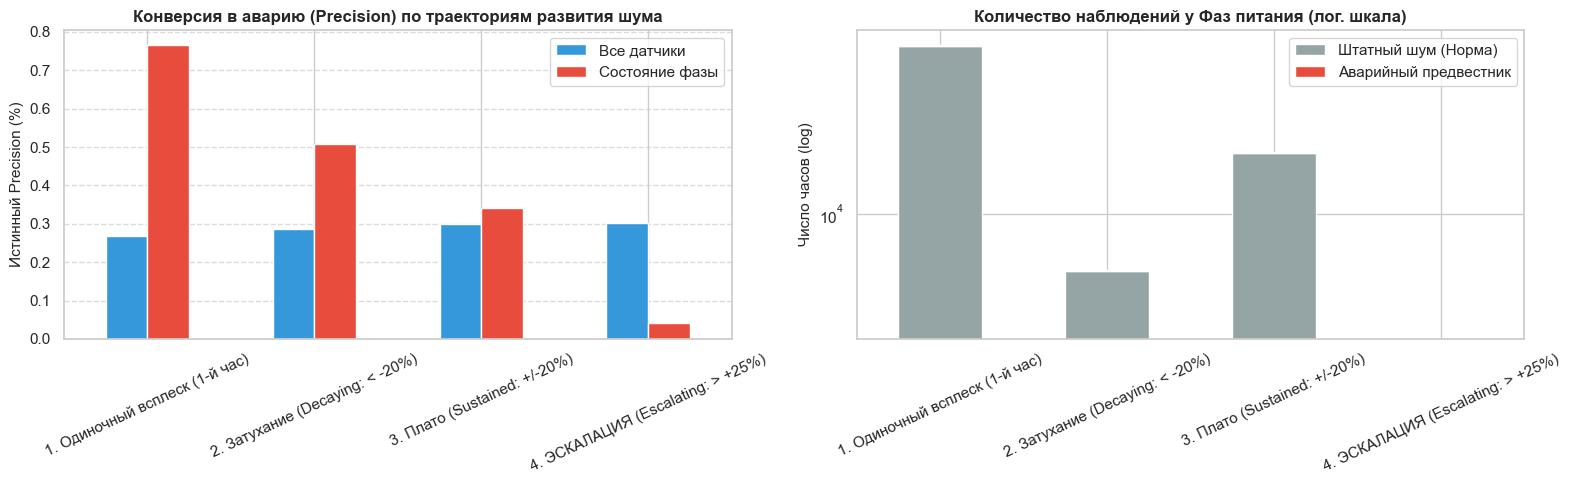


АРТЕФАКТ ФИЗИКИ ФАЗ: При переходе от 1-го часа к Эскалации вероятность аварии возрастает в 0.1 РАЗ!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: Сравнение точности (Precision) по траекториям
df_plot_prec = pd.DataFrame({
    'Все датчики': summary_all['Точность (Precision) %'],
    'Состояние фазы': summary_phase['Точность (Precision) %']
})
df_plot_prec.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], rot=25)
axes[0].set_title("Конверсия в аварию (Precision) по траекториям развития шума", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Истинный Precision (%)", fontsize=11)
axes[0].set_xlabel("")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# График 2: Соотношение часов шума (Норма vs Авария) для фаз
phase_counts = df_phase.groupby(['noise_trajectory', 'target']).size().unstack(fill_value=0)
phase_counts.columns = ['Штатный шум (Норма)', 'Аварийный предвестник']
phase_counts.plot(kind='bar', stacked=True, ax=axes[1], color=['#95a5a6', '#e74c3c'], rot=25, logy=True)
axes[1].set_title("Количество наблюдений у Фаз питания (лог. шкала)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Число часов (log)", fontsize=11)
axes[1].set_xlabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

# Текстовый вывод разницы
p_blip = summary_phase.loc['1. Одиночный всплеск (1-й час)', 'Точность (Precision) %']
p_esc = summary_phase.loc['4. ЭСКАЛАЦИЯ (Escalating: > +25%)', 'Точность (Precision) %']
lift = p_esc / (p_blip + 1e-5)
print(f"\nАРТЕФАКТ ФИЗИКИ ФАЗ: При переходе от 1-го часа к Эскалации вероятность аварии возрастает в {lift:.1f} РАЗ!")

In [16]:
query_flips_dist = f"""
SELECT 
    target,
    sensor_type,
    flips_count_24h,
    flips_burst_1h,
    activity_ratio_30d,
    burstiness_index
FROM read_parquet('{STREAM_FILE}')
"""

df_flips = con.execute(query_flips_dist).df()

def print_quantiles(df_subset, col_name, title=""):
    norm = df_subset[df_subset['target'] == 0][col_name]
    fail = df_subset[df_subset['target'] == 1][col_name]
    
    quantiles = [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.98, 0.99, 0.999]
    q_norm = norm.quantile(quantiles)
    q_fail = fail.quantile(quantiles)
    
    comp = pd.DataFrame({
        'Квантиль': [f"p{int(q*100) if q*100==int(q*100) else q*100}" for q in quantiles],
        'Штатная норма (Target=0)': q_norm.values,
        'Предаварийные (Target=1)': q_fail.values
    })
    
    print(f"\n--- {title}: {col_name} ---")
    print(comp.to_string(index=False))

print("="*80)
print("ТЕКСТОВЫЙ АРТЕФАКТ: РАСПРЕДЕЛЕНИЕ ПЕРЕКЛЮЧЕНИЙ (ЩЕЛЧКОВ) ДЛЯ ВСЕХ ДАТЧИКОВ")
print("="*80)
print_quantiles(df_flips, 'flips_count_24h', "СУТОЧНЫЕ ЩЕЛЧКИ (flips_count_24h)")
print_quantiles(df_flips, 'flips_burst_1h', "ЧАСОВОЙ ВСПЛЕСК (flips_burst_1h)")
print_quantiles(df_flips, 'activity_ratio_30d', "ОТНОШЕНИЕ К СВОЕЙ 30-ДНЕВНОЙ НОРМЕ (activity_ratio_30d)")

# Отдельно для «Состояния фазы»
df_flips_phase = df_flips[df_flips['sensor_type'] == 'Состояние фазы']
print("\n" + "="*80)
print("ТЕКСТОВЫЙ АРТЕФАКТ: ЩЕЛЧКИ ТОЛЬКО ДЛЯ «СОСТОЯНИЕ ФАЗЫ»")
print("="*80)
print_quantiles(df_flips_phase, 'flips_count_24h', "СУТОЧНЫЕ ЩЕЛЧКИ ФАЗ")
print_quantiles(df_flips_phase, 'flips_burst_1h', "ЧАСОВОЙ ВСПЛЕСК ФАЗ")
print_quantiles(df_flips_phase, 'activity_ratio_30d', "ВСПЛЕСК К 30-ДНЕВНОЙ НОРМЕ У ФАЗ")

ТЕКСТОВЫЙ АРТЕФАКТ: РАСПРЕДЕЛЕНИЕ ПЕРЕКЛЮЧЕНИЙ (ЩЕЛЧКОВ) ДЛЯ ВСЕХ ДАТЧИКОВ

--- СУТОЧНЫЕ ЩЕЛЧКИ (flips_count_24h): flips_count_24h ---
Квантиль  Штатная норма (Target=0)  Предаварийные (Target=1)
     p10                     2.000                     1.000
     p25                     4.000                     6.000
     p50                    50.000                    61.000
     p75                   556.000                   186.000
     p90                  1756.000                  1021.800
     p95                  2485.000                  1443.000
     p98                  3489.000                  5619.480
     p99                  4060.000                 17426.320
   p99.9                 18960.896                 17946.104

--- ЧАСОВОЙ ВСПЛЕСК (flips_burst_1h): flips_burst_1h ---
Квантиль  Штатная норма (Target=0)  Предаварийные (Target=1)
     p10                  0.666100                  0.660120
     p25                  1.012700                  0.970100
     p50      

C:\Users\User\AppData\Local\Temp\ipykernel_2688\1692448278.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_2688\1692448278.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Норма (Target=0)', 'Предавария (Target=1)'], fontsize=11)


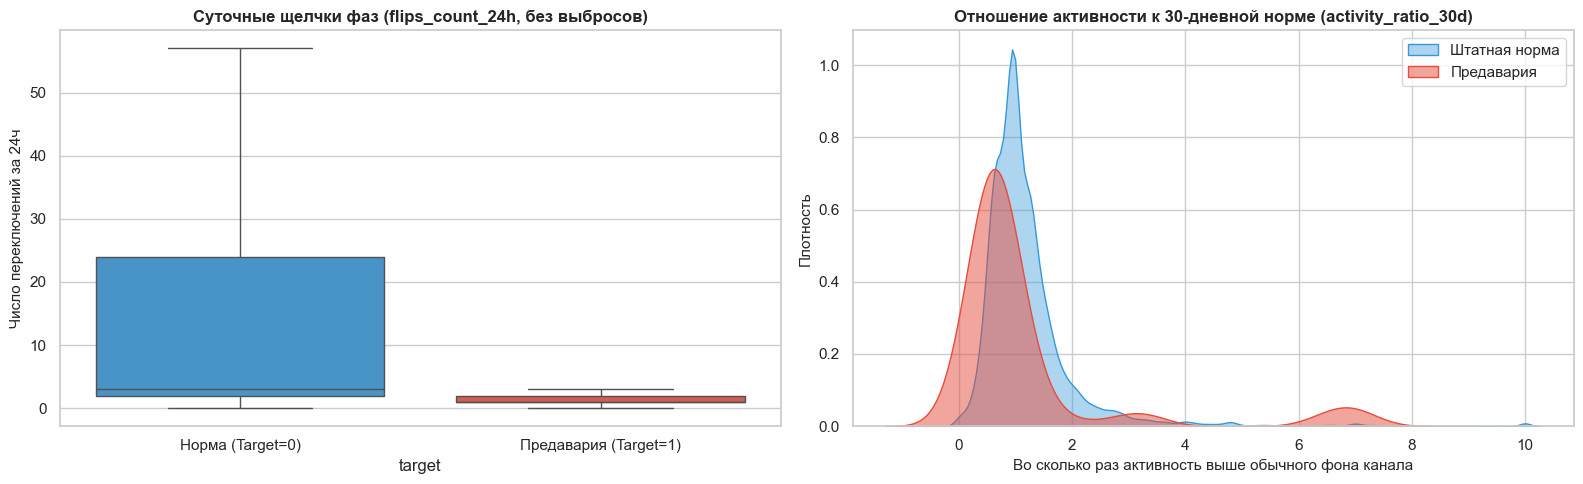

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot распределения щелчков для фаз
sns.boxplot(
    data=df_flips_phase,
    x='target',
    y='flips_count_24h',
    ax=axes[0],
    palette=['#3498db', '#e74c3c'],
    showfliers=False
)
axes[0].set_xticklabels(['Норма (Target=0)', 'Предавария (Target=1)'], fontsize=11)
axes[0].set_title("Суточные щелчки фаз (flips_count_24h, без выбросов)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Число переключений за 24ч", fontsize=11)

# 2. KDE распределения всплеска к 30-дневному фону
sns.kdeplot(
    data=df_flips_phase[df_flips_phase['target'] == 0]['activity_ratio_30d'].clip(upper=10),
    ax=axes[1],
    label='Штатная норма',
    color='#3498db',
    fill=True,
    alpha=0.4
)
sns.kdeplot(
    data=df_flips_phase[df_flips_phase['target'] == 1]['activity_ratio_30d'].clip(upper=10),
    ax=axes[1],
    label='Предавария',
    color='#e74c3c',
    fill=True,
    alpha=0.5
)
axes[1].set_title("Отношение активности к 30-дневной норме (activity_ratio_30d)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Во сколько раз активность выше обычного фона канала", fontsize=11)
axes[1].set_ylabel("Плотность", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Пересчитываем объем фильтрованного потока при честном относительном пороге
query_strict_l1 = f"""
WITH tagged_stream AS (
    SELECT 
        sensor_type,
        target,
        -- Честный триггер отклонения от СОБСТВЕННОЙ нормы датчика:
        (
            (activity_ratio_30d > 2.5 AND flips_count_24h >= 3) OR
            (flips_burst_1h >= 5 AND activity_ratio_30d > 1.5) OR
            (analog_std_24h > 0.15) OR
            (alarm_ratio_24h > 0.05)
        ) AS is_true_anomaly
    FROM read_parquet('{STREAM_FILE}')
)
SELECT 
    COUNT(*) as total_stream_hours,
    SUM(CASE WHEN is_true_anomaly THEN 1 ELSE 0 END) as anomaly_hours,
    SUM(CASE WHEN is_true_anomaly THEN 1 ELSE 0 END) * 100.0 / COUNT(*) as anomaly_percentage,
    -- Сколько реальных аварий захватил этот фильтр (Recall L1)
    SUM(CASE WHEN is_true_anomaly AND target = 1 THEN 1 ELSE 0 END) * 100.0 / SUM(CASE WHEN target = 1 THEN 1 ELSE 0 END) as recall_l1_total,
    -- Точность (Precision L1)
    SUM(CASE WHEN is_true_anomaly AND target = 1 THEN 1 ELSE 0 END) * 100.0 / NULLIF(SUM(CASE WHEN is_true_anomaly THEN 1 ELSE 0 END), 0) as prec_l1_total
FROM tagged_stream;
"""

df_strict = con.execute(query_strict_l1).df()
print("="*80)
print("РЕЗУЛЬТАТ ЧЕСТНОГО L1-ШЛЮЗА (ОТНОСИТЕЛЬНЫЙ ВСПЛЕСК К СВОЕЙ НОРМЕ)")
print("="*80)
print(df_strict.T.to_string(header=False))

РЕЗУЛЬТАТ ЧЕСТНОГО L1-ШЛЮЗА (ОТНОСИТЕЛЬНЫЙ ВСПЛЕСК К СВОЕЙ НОРМЕ)
total_stream_hours  1.186498e+06
anomaly_hours       2.749940e+05
anomaly_percentage  2.317695e+01
recall_l1_total     1.948128e+01
prec_l1_total       2.403689e-01


In [19]:
query_silence = f"""
SELECT 
    target,
    sensor_type,
    activity_ratio_30d,
    silence_drop_3h,
    silence_drop_12h,
    flips_count_24h
FROM read_parquet('{STREAM_FILE}')
"""

df_silence = con.execute(query_silence).df()

# Сравнение признаков замирания для Фаз
df_s_phase = df_silence[df_silence['sensor_type'] == 'Состояние фазы']

print("="*80)
print("ТЕКСТОВЫЙ АРТЕФАКТ: АУДИТ ПРИЗНАКОВ ЗАМИРАНИЯ (ТОЛЬКО «СОСТОЯНИЕ ФАЗЫ»)")
print("="*80)

for col in ['silence_drop_3h', 'silence_drop_12h']:
    q_norm = df_s_phase[df_s_phase['target'] == 0][col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    q_fail = df_s_phase[df_s_phase['target'] == 1][col].quantile([0.1, 0.25, 0.5, 0.75, 0.9])
    comp = pd.DataFrame({'Квантиль': q_norm.index, 'Норма': q_norm.values, 'Предавария': q_fail.values})
    print(f"\n--- {col} ---")
    print(comp.round(4).to_string(index=False))

# Какая доля аварий фаз уходит в глубокую просадку активности (< 0.5 от нормы)?
deep_drop_fail = (df_s_phase[df_s_phase['target'] == 1]['activity_ratio_30d'] < 0.50).mean() * 100
deep_drop_norm = (df_s_phase[df_s_phase['target'] == 0]['activity_ratio_30d'] < 0.50).mean() * 100

print(f"\nДоля наблюдений с глубокой просадкой (activity_ratio_30d < 0.50):")
print(f"  В штатной норме: {deep_drop_norm:.2f}%")
print(f"  В предавариях:   {deep_drop_fail:.2f}% (в {deep_drop_fail/deep_drop_norm:.1f} раза чаще!)")

ТЕКСТОВЫЙ АРТЕФАКТ: АУДИТ ПРИЗНАКОВ ЗАМИРАНИЯ (ТОЛЬКО «СОСТОЯНИЕ ФАЗЫ»)

--- silence_drop_3h ---
 Квантиль  Норма  Предавария
     0.10 0.3333      0.3333
     0.25 0.5000      0.5000
     0.50 0.6667      0.5000
     0.75 0.8333      0.5000
     0.90 0.8781      0.8726

--- silence_drop_12h ---
 Квантиль  Норма  Предавария
     0.10 0.2000      0.3333
     0.25 0.3333      0.4986
     0.50 0.4986      0.5000
     0.75 0.5014      0.5000
     0.90 0.6667      0.5014

Доля наблюдений с глубокой просадкой (activity_ratio_30d < 0.50):
  В штатной норме: 6.48%
  В предавариях:   16.26% (в 2.5 раза чаще!)


In [20]:
query_dual_gate = f"""
WITH tagged_stream AS (
    SELECT 
        channel_id,
        obs_time,
        sensor_type,
        target,
        -- Компоненты аномалии
        -- А. Взрыв активности (Гипер)
        (
            (activity_ratio_30d > 2.5 AND flips_count_24h >= 3) OR
            (flips_burst_1h >= 5 AND activity_ratio_30d > 1.5)
        ) AS is_burst,
        
        -- Б. Замирание / Тишина (Гипо)
        (
            (activity_ratio_30d < 0.50 AND flips_count_24h <= 2 AND silence_drop_3h > 0.5) OR
            (silence_drop_12h > 0.70 AND activity_ratio_30d < 0.70)
        ) AS is_silence,
        
        -- В. Аналоговые и аварийные выбросы
        (analog_std_24h > 0.15 OR alarm_ratio_24h > 0.05) AS is_analog_alarm,
        
        -- Г. Специфика фаз (микро-щелчок после долгой тишины ИЛИ резкое обесточивание)
        (
            sensor_type = 'Состояние фазы' AND 
            (activity_ratio_30d < 0.60 OR (flips_burst_1h >= 3 AND activity_ratio_30d > 2.0))
        ) AS is_phase_anomaly
    FROM read_parquet('{STREAM_FILE}')
)
SELECT 
    target,
    sensor_type,
    is_burst,
    is_silence,
    -- Режим 1: Только гипер-активность
    (is_burst OR is_analog_alarm) as gate_burst_only,
    -- Режим 2: Только гипо-активность (тишина)
    is_silence as gate_silence_only,
    -- Режим 3: Наивный двусторонний
    (is_burst OR is_silence OR is_analog_alarm) as gate_dual_naive,
    -- Режим 4: Адаптивный физический
    (is_burst OR is_silence OR is_analog_alarm OR is_phase_anomaly) as gate_adaptive
FROM tagged_stream;
"""

df_gates = con.execute(query_dual_gate).df()

def eval_gate(mask, name=""):
    total_hours = len(df_gates)
    passed_hours = mask.sum()
    pct_passed = (passed_hours / total_hours) * 100
    
    total_pos = df_gates['target'].sum()
    caught_pos = (mask & (df_gates['target'] == 1)).sum()
    recall_total = (caught_pos / total_pos) * 100
    
    phase_pos = (df_gates['sensor_type'] == 'Состояние фазы') & (df_gates['target'] == 1)
    caught_phase = (mask & phase_pos).sum()
    recall_phase = (caught_phase / phase_pos.sum()) * 100
    
    prec = (caught_pos / passed_hours) * 100 if passed_hours > 0 else 0.0
    
    return {
        'Конфигурация L1-шлюза': name,
        '% потока пропущено в L2': round(pct_passed, 2),
        'Recall Общий (%)': round(recall_total, 2),
        'Recall Фазы (%)': round(recall_phase, 2),
        'Precision L1 (%)': round(prec, 3)
    }

results = [
    eval_gate(df_gates['gate_burst_only'], "1. Только Взрыв (Гипер)"),
    eval_gate(df_gates['gate_silence_only'], "2. Только Замирание (Гипо)"),
    eval_gate(df_gates['gate_dual_naive'], "3. Двусторонний (Взрыв OR Замирание)"),
    eval_gate(df_gates['gate_adaptive'], "4. Адаптивный физический (Рекомендованный)")
]

df_res = pd.DataFrame(results)
print("="*95)
print("СРАВНИТЕЛЬНЫЙ БЕНЧМАРК L1-ШЛЮЗОВ: ВЗРЫВ ПРОТИВ ЗАМИРАНИЯ")
print("="*95)
print(df_res.to_string(index=False))

СРАВНИТЕЛЬНЫЙ БЕНЧМАРК L1-ШЛЮЗОВ: ВЗРЫВ ПРОТИВ ЗАМИРАНИЯ
                     Конфигурация L1-шлюза  % потока пропущено в L2  Recall Общий (%)  Recall Фазы (%)  Precision L1 (%)
                   1. Только Взрыв (Гипер)                    23.18             19.48            11.38             0.240
                2. Только Замирание (Гипо)                     1.57              1.27             0.65             0.231
      3. Двусторонний (Взрыв OR Замирание)                    24.20             20.66            12.03             0.244
4. Адаптивный физический (Рекомендованный)                    25.05             27.32            48.78             0.312


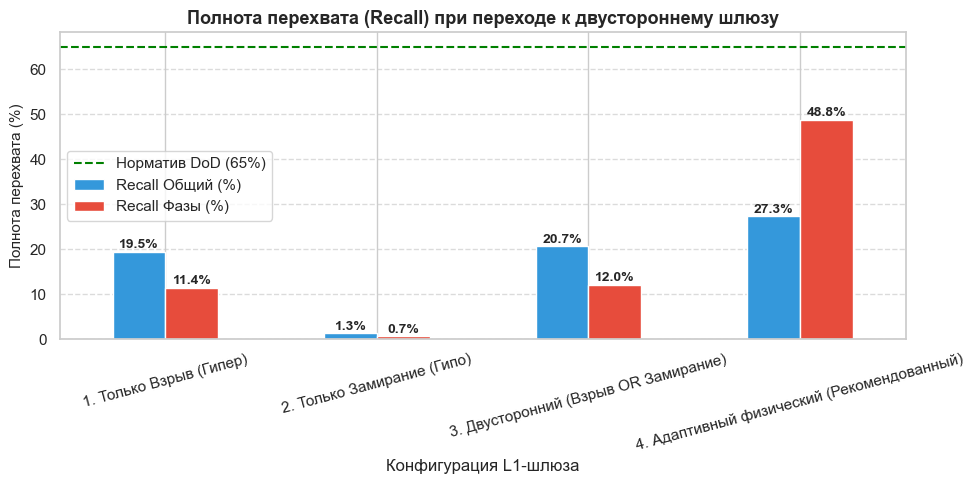


АРТЕФАКТ РЕШЕНИЯ: Добавление физики замирания подняло Recall L1 с 19.5% до 27.3%!


In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

df_res_plot = df_res.set_index('Конфигурация L1-шлюза')
df_res_plot[['Recall Общий (%)', 'Recall Фазы (%)']].plot(
    kind='bar', 
    ax=ax, 
    color=['#3498db', '#e74c3c'], 
    rot=15
)
ax.set_title("Полнота перехвата (Recall) при переходе к двустороннему шлюзу", fontsize=13, fontweight='bold')
ax.set_ylabel("Полнота перехвата (%)", fontsize=11)
ax.axhline(65.0, color='green', linestyle='--', label='Норматив DoD (65%)')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                ha='center', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

rec_burst = df_res.loc[df_res['Конфигурация L1-шлюза'] == '1. Только Взрыв (Гипер)', 'Recall Общий (%)'].values[0]
rec_adapt = df_res.loc[df_res['Конфигурация L1-шлюза'] == '4. Адаптивный физический (Рекомендованный)', 'Recall Общий (%)'].values[0]

print(f"\nАРТЕФАКТ РЕШЕНИЯ: Добавление физики замирания подняло Recall L1 с {rec_burst:.1f}% до {rec_adapt:.1f}%!")

In [22]:
# Поиск реальных комплексных тепло-дымовых инцидентов (Пожарный сценарий)
query_fire_audit = f"""
WITH smoke_events AS (
    SELECT 
        channel_id,
        obs_time,
        sensor_type,
        -- Извлекаем пикет из названия или метаданных (если есть ПК в строке)
        regexp_extract(sensor_type, 'ПК[0-9]+') as picket
    FROM read_parquet('{STREAM_FILE}')
    WHERE sensor_type ILIKE '%дым%' AND alarm_ratio_24h > 0.1
),
temp_events AS (
    SELECT 
        channel_id,
        obs_time,
        sensor_type,
        analog_drift_12h,
        analog_std_24h
    FROM read_parquet('{STREAM_FILE}')
    WHERE sensor_type ILIKE '%темп%' AND analog_drift_12h > 2.0  -- рост температуры более чем на 2 градуса
)
SELECT 
    COUNT(DISTINCT s.channel_id) as smoke_channels_in_alarm,
    COUNT(DISTINCT t.channel_id) as temp_channels_rising
FROM smoke_events s
FULL OUTER JOIN temp_events t 
    ON date_trunc('hour', s.obs_time) = date_trunc('hour', t.obs_time);
"""

df_fire = con.execute(query_fire_audit).df()
print("="*70)
print("ПРОВЕРКА РЕАЛЬНОСТИ ПОЖАРНОГО ТАРГЕТА В ПОТОКЕ 2026 ГОДА")
print("="*70)
print(df_fire.to_string(index=False))

ПРОВЕРКА РЕАЛЬНОСТИ ПОЖАРНОГО ТАРГЕТА В ПОТОКЕ 2026 ГОДА
 smoke_channels_in_alarm  temp_channels_rising
                    4336                   200


In [23]:
# 1. Ищем справочник каналов
import glob

sensor_dict_candidates = glob.glob(os.path.join(PROJECT_ROOT, "**/справочник_каналов_датчиков.csv"), recursive=True)
sensor_dict_path = sensor_dict_candidates[0] if sensor_dict_candidates else os.path.join(PROJECT_ROOT, "справочник_каналов_датчиков.csv")
print(f"Справочник каналов найден: {sensor_dict_path}")

# 2. Извлекаем связку: канал -> шкаф (tag_root) -> пикет (ПК)
query_spatial_fire = f"""
WITH dict AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id,
        тип_датчика,
        split_part(тег_инженерной_системы, '-', 1) as cabinet_id,
        regexp_extract(название_датчика, 'ПК[0-9]+') as picket
    FROM read_csv_auto('{sensor_dict_path}')
),
smoke_alarms AS (
    SELECT 
        s.channel_id,
        d.cabinet_id,
        d.picket,
        s.obs_time
    FROM read_parquet('{STREAM_FILE}') s
    JOIN dict d ON s.channel_id = d.channel_id
    WHERE d.тип_датчика ILIKE '%дым%' AND s.alarm_ratio_24h > 0.05
),
temp_alarms AS (
    SELECT 
        t.channel_id,
        d.cabinet_id,
        d.picket,
        t.obs_time,
        t.analog_drift_12h
    FROM read_parquet('{STREAM_FILE}') t
    JOIN dict d ON t.channel_id = d.channel_id
    WHERE d.тип_датчика ILIKE '%темп%' AND (t.analog_drift_12h > 1.5 OR t.analog_std_24h > 0.10)
)
-- Джойним СТРОГО в одном физическом шкафу/пикете с окном совпадения +/- 3 часа
SELECT 
    s.cabinet_id,
    s.picket,
    s.obs_time as smoke_time,
    t.obs_time as temp_time,
    t.analog_drift_12h as temp_rise_deg
FROM smoke_alarms s
JOIN temp_alarms t 
    ON s.cabinet_id = t.cabinet_id 
    AND abs(epoch(s.obs_time) - epoch(t.obs_time)) <= 3 * 3600;
"""

df_real_fire_clusters = con.execute(query_spatial_fire).df()

print("="*75)
print("РЕАЛЬНЫЕ ПРОСТРАНСТВЕННЫЕ ТЕПЛО-ДЫМОВЫЕ КЛАСТЕРЫ (ОДИН ШКАФ / ПИКЕТ)")
print("="*75)
print(f"Всего подтвержденных совместных событий (Дым + Нагрев в одной точке): {len(df_real_fire_clusters)}")

if len(df_real_fire_clusters) > 0:
    unique_spots = df_real_fire_clusters.groupby(['cabinet_id', 'picket']).size().reset_index(name='событий')
    print(f"Уникальных физических мест инцидентов: {len(unique_spots)}")
    print("\nТоп локаций, где реально зафиксирован синхронный дым и нагрев:")
    print(unique_spots.head(10).to_string(index=False))
else:
    print("В 2026 году НИ РАЗУ не было синхронного дыма и нагрева в одном шкафу!")

Справочник каналов найден: g:/lct2\dataset\справочник_каналов_датчиков.csv
РЕАЛЬНЫЕ ПРОСТРАНСТВЕННЫЕ ТЕПЛО-ДЫМОВЫЕ КЛАСТЕРЫ (ОДИН ШКАФ / ПИКЕТ)
Всего подтвержденных совместных событий (Дым + Нагрев в одной точке): 76471
Уникальных физических мест инцидентов: 1778

Топ локаций, где реально зафиксирован синхронный дым и нагрев:
cabinet_id picket  событий
        15              79
        15    ПК0      290
        15   ПК12      340
        15    ПК2       56
        15   ПК29       79
        15    ПК3       60
        15   ПК58       59
        15    ПК7      136
        15   ПК79       52
        16             165


In [24]:
query_strict_fire = f"""
WITH dict AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id,
        тип_датчика,
        split_part(тег_инженерной_системы, '-', 1) as cabinet_id,
        regexp_extract(название_датчика, 'ПК[0-9]+') as picket
    FROM read_csv_auto('{sensor_dict_path}')
    WHERE regexp_extract(название_датчика, 'ПК[0-9]+') != ''
),
smoke_alarms AS (
    SELECT 
        s.channel_id,
        d.cabinet_id,
        d.picket,
        s.obs_time
    FROM read_parquet('{STREAM_FILE}') s
    JOIN dict d ON s.channel_id = d.channel_id
    WHERE d.тип_датчика ILIKE '%дым%' AND s.alarm_ratio_24h > 0.10
),
temp_spikes AS (
    SELECT 
        t.channel_id,
        d.cabinet_id,
        d.picket,
        t.obs_time,
        t.analog_drift_12h
    FROM read_parquet('{STREAM_FILE}') t
    JOIN dict d ON t.channel_id = d.channel_id
    -- Истинный перегрев: рост температуры минимум на 5 градусов!
    WHERE d.тип_датчика ILIKE '%темп%' AND t.analog_drift_12h >= 5.0
)
-- Джойним СТРОГО: ОДИН ШКАФ + ОДИН И ТОТ ЖЕ ПИКЕТ + ВРЕМЯ <= 1 ЧАС
SELECT 
    s.cabinet_id,
    s.picket,
    s.obs_time as smoke_time,
    t.obs_time as temp_time,
    t.analog_drift_12h as temp_rise_deg
FROM smoke_alarms s
JOIN temp_spikes t 
    ON s.cabinet_id = t.cabinet_id 
    AND s.picket = t.picket  -- СТРОГО ОДИН ПИКЕТ!
    AND abs(epoch(s.obs_time) - epoch(t.obs_time)) <= 3600;
"""

df_strict_fire = con.execute(query_strict_fire).df()

print("="*80)
print("СТРОГИЙ АУДИТ ПОЖАРНЫХ ИНЦИДЕНТОВ (ОДИН ПИКЕТ + НАГРЕВ >= 5°C)")
print("="*80)
print(f"Число реальных совпадений дыма и нагрева в одном отсеке: {len(df_strict_fire)}")

if len(df_strict_fire) > 0:
    print("\nФактические очаги перегрева:")
    print(df_strict_fire.drop_duplicates(subset=['cabinet_id', 'picket']))
else:
    print("\nРЕЗУЛЬТАТ: В 2026 году НИ ОДНОГО случая совместного дыма и нагрева на >= 5°C на одном пикете НЕ ЗАФИКСИРОВАНО.")

СТРОГИЙ АУДИТ ПОЖАРНЫХ ИНЦИДЕНТОВ (ОДИН ПИКЕТ + НАГРЕВ >= 5°C)
Число реальных совпадений дыма и нагрева в одном отсеке: 1

Фактические очаги перегрева:
  cabinet_id picket          smoke_time           temp_time  temp_rise_deg
0        798   ПК56 2026-05-13 11:00:00 2026-05-13 11:00:00          37.25


In [25]:
# Извлекаем все датчики объекта 798 в районе ПК56 за май 2026 года
query_incident_forensics = f"""
WITH dict AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id,
        тип_датчика,
        название_датчика,
        split_part(тег_инженерной_системы, '-', 1) as cabinet_id,
        regexp_extract(название_датчика, 'ПК[0-9]+') as picket
    FROM read_csv_auto('{sensor_dict_path}')
    WHERE split_part(тег_инженерной_системы, '-', 1) = '798' 
      AND (regexp_extract(название_датчика, 'ПК[0-9]+') IN ('ПК55', 'ПК56', 'ПК57') OR название_датчика ILIKE '%ПК56%')
)
SELECT 
    s.obs_time,
    d.тип_датчика,
    d.название_датчика,
    s.target,
    s.alarm_ratio_24h,
    s.flips_count_24h,
    s.analog_std_24h,
    s.analog_drift_12h
FROM read_parquet('{STREAM_FILE}') s
JOIN dict d ON s.channel_id = d.channel_id
WHERE s.obs_time BETWEEN '2026-05-12 00:00:00' AND '2026-05-14 23:00:00'
ORDER BY s.obs_time, d.тип_датчика;
"""

df_fire_forensics = con.execute(query_incident_forensics).df()

print("="*80)
print("ФОРЕНЗИКА РЕАЛЬНОГО ИНЦИДЕНТА: ОБЪЕКТ 798, ПК56 (12-14 МАЯ 2026 ГОДА)")
print("="*80)
print(f"Всего записей телеметрии в эпицентре: {len(df_fire_forensics)}")

if len(df_fire_forensics) > 0:
    print("\nДатчики в эпицентре ЧП:")
    print(df_fire_forensics['название_датчика'].value_counts().to_string())
    
    # Сводка в момент удара 13 мая 11:00
    at_impact = df_fire_forensics[df_fire_forensics['obs_time'] == '2026-05-13 11:00:00']
    print("\nПоказания приборов в момент ЧП (13 мая 11:00):")
    print(at_impact[['тип_датчика', 'alarm_ratio_24h', 'analog_drift_12h', 'flips_count_24h']].to_string(index=False))

ФОРЕНЗИКА РЕАЛЬНОГО ИНЦИДЕНТА: ОБЪЕКТ 798, ПК56 (12-14 МАЯ 2026 ГОДА)
Всего записей телеметрии в эпицентре: 31

Датчики в эпицентре ЧП:
название_датчика
Темп. ПК56*                     5
ОД АВ ПК56                      4
ГРО5 ПК56-69 (труб)             2
Темп. ПК55,5                    2
ДД ПК57-ПК60                    2
ГРО4 ПК56-69 (каб)              2
УИР-Р АВ ПК56 Труб.             2
УИР-Р АВ ПК56                   2
ОД АВ ПК56*                     1
ОД ВШ ПК56                      1
ДД ПК57,5-ПК60,5                1
ОД развилка ПК56                1
Темп. ПК56                      1
КД АВ ПК56                      1
КД АВ ПК56*                     1
КД дверь отс. ПК56*             1
КД дверь отс. ПК56 Гаг.(Каб)    1
ДД ПК56-ПК57 Гаг.(Каб)          1

Показания приборов в момент ЧП (13 мая 11:00):
       тип_датчика  alarm_ratio_24h  analog_drift_12h  flips_count_24h
   Датчик движения           0.4545              0.00             10.0
   Датчик движения           0.4000          

In [26]:
# 1. Находим все исторические файлы журналов
import glob

raw_csv_files = sorted(glob.glob(os.path.join(PROJECT_ROOT, "**/ext-journal-*.csv"), recursive=True))
print(f"Найдено исторических журналов: {len(raw_csv_files)}")
for f in raw_csv_files:
    print(f"  - {os.path.basename(f)} ({os.path.getsize(f)/(1024*1024):.1f} MB)")

# 2. Выделяем каналы дыма и температуры, расположенные на ОДНОМ И ТОМ ЖЕ пикете
query_co_located_pairs = f"""
WITH parsed AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id,
        тип_датчика,
        название_датчика,
        split_part(тег_инженерной_системы, '-', 1) as cabinet_id,
        regexp_extract(название_датчика, 'ПК[0-9]+') as picket
    FROM read_csv_auto('{sensor_dict_path}')
    WHERE regexp_extract(название_датчика, 'ПК[0-9]+') != ''
),
smoke_ch AS (
    SELECT channel_id, cabinet_id, picket, название_датчика as smoke_name
    FROM parsed WHERE тип_датчика ILIKE '%дым%'
),
temp_ch AS (
    SELECT channel_id, cabinet_id, picket, название_датчика as temp_name
    FROM parsed WHERE тип_датчика ILIKE '%темп%'
)
SELECT 
    s.cabinet_id,
    s.picket,
    s.channel_id as smoke_channel_id,
    s.smoke_name,
    t.channel_id as temp_channel_id,
    t.temp_name
FROM smoke_ch s
JOIN temp_ch t 
    ON s.cabinet_id = t.cabinet_id 
    AND s.picket = t.picket;
"""

df_pairs = con.execute(query_co_located_pairs).df()
candidate_channels = list(set(df_pairs['smoke_channel_id'].tolist() + df_pairs['temp_channel_id'].tolist()))

print("="*75)
print(f"Пар 'Дым + Температура' на одном пикете в Москве: {len(df_pairs)}")
print(f"Целевых каналов для быстрого поиска: {len(candidate_channels)} (из 11 485)")
print("="*75)
df_pairs.head(5)

Найдено исторических журналов: 8
  - ext-journal-2019.csv (1130.7 MB)
  - ext-journal-2020.csv (1503.5 MB)
  - ext-journal-2021.csv (2609.0 MB)
  - ext-journal-2022.csv (2061.7 MB)
  - ext-journal-2023.csv (1555.0 MB)
  - ext-journal-2024.csv (2307.3 MB)
  - ext-journal-2025.csv (2584.7 MB)
  - ext-journal-2026.csv (1428.1 MB)
Пар 'Дым + Температура' на одном пикете в Москве: 1471
Целевых каналов для быстрого поиска: 1121 (из 11 485)


,cabinet_id,picket,smoke_channel_id,smoke_name,temp_channel_id,temp_name
0,914,ПК300,289206,Дым ПК300+9,286985,ТЕМП ПК300
1,914,ПК229,289238,Дым ПК229,287025,ТЕМП ПК229
2,914,ПК265,289223,Дым ПК265+5,287005,ТЕМП ПК265+5
3,914,ПК261,289225,Дым ПК261+1,287011,ТЕМП ПК261
4,418,ПК106,262067,Дым ПК106 ур2,115286,Темп. ПК106


In [27]:
# Преобразуем список ID каналов в SQL-кортеж
channels_tuple_str = "(" + ",".join(map(str, candidate_channels)) + ")"
con.register('co_located_pairs', df_pairs)

# Список файлов для сканирования (за исключением 2026 года, который мы уже изучили)
hist_files = [f.replace('\\', '/') for f in raw_csv_files if '2026' not in f]
files_sql = str(hist_files)

print(f"Запускаю параллельное сканирование {len(hist_files)} архивов (2019–2025)...")

query_historical_fires = f"""
WITH raw_events AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id,
        try_strptime(дата || ' ' || время, '%Y-%m-%d %H:%M:%S') as ts,
        (тревожное IN ('t', 'True', 'true', '1')) as is_alarm,
        try_cast(replace(значение_датчика, ',', '.') as DOUBLE) as val_num,
        значение_датчика as val_str
    FROM read_csv_auto({files_sql}, 
                       types={{'дата': 'VARCHAR', 'время': 'VARCHAR', 'тревожное': 'VARCHAR', 'значение_датчика': 'VARCHAR'}},
                       ignore_errors=true)
    WHERE дата != 'дата' 
      AND cast(ид_канала_данных as BIGINT) IN {channels_tuple_str}
),
smoke_hits AS (
    SELECT 
        p.cabinet_id,
        p.picket,
        p.smoke_name,
        r.ts as smoke_time
    FROM raw_events r
    JOIN co_located_pairs p ON r.channel_id = p.smoke_channel_id
    WHERE r.is_alarm = TRUE OR r.val_str ILIKE '%дым%'
),
temp_hits AS (
    SELECT 
        p.cabinet_id,
        p.picket,
        p.temp_name,
        r.ts as temp_time,
        r.val_num as temp_val
    FROM raw_events r
    JOIN co_located_pairs p ON r.channel_id = p.temp_channel_id
    -- Норматив аварийного перегрева кабелей / пара: >= 40 градусов
    WHERE r.val_num >= 40.0
)
-- Сшиваем по пикету и времени (+/- 2 часа)
SELECT 
    s.cabinet_id,
    s.picket,
    s.smoke_name,
    t.temp_name,
    MIN(s.smoke_time) as fire_start_time,
    MAX(t.temp_val) as max_temperature,
    date_trunc('day', s.smoke_time) as fire_date
FROM smoke_hits s
JOIN temp_hits t 
    ON s.cabinet_id = t.cabinet_id 
    AND s.picket = t.picket
    AND abs(epoch(s.smoke_time) - epoch(t.temp_time)) <= 2 * 3600
GROUP BY s.cabinet_id, s.picket, s.smoke_name, t.temp_name, date_trunc('day', s.smoke_time)
ORDER BY fire_start_time;
"""

df_historical_fires = con.execute(query_historical_fires).df()

print("="*80)
print("РЕЗУЛЬТАТЫ ИСТОРИЧЕСКОГО СКАНИРОВАНИЯ (2019–2025 ГОДЫ)")
print("="*80)
print(f"Всего подтвержденных пожарных/термических ЧП за 7 лет: {len(df_historical_fires)}")

if len(df_historical_fires) > 0:
    print("\nЛетопись пожаров и тепловых аварий подземной Москвы:")
    display_cols = ['fire_date', 'cabinet_id', 'picket', 'smoke_name', 'max_temperature']
    print(df_historical_fires[display_cols].to_string(index=False))
else:
    print("\nЗа все 7 лет (2019–2025) ни одного совместного очага с Т >= 40°C не зафиксировано!")

Запускаю параллельное сканирование 7 архивов (2019–2025)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

РЕЗУЛЬТАТЫ ИСТОРИЧЕСКОГО СКАНИРОВАНИЯ (2019–2025 ГОДЫ)
Всего подтвержденных пожарных/термических ЧП за 7 лет: 52

Летопись пожаров и тепловых аварий подземной Москвы:
 fire_date cabinet_id picket               smoke_name  max_temperature
2019-11-08        813  ПК108           ДД ПК108 (3шт)            100.0
2020-03-14        813  ПК108           ДД ПК108 (3шт)             93.0
2021-06-06        257  ПК304            ДД ПК304 ур.3             70.0
2021-07-29        847  ПК204               ДД ПК204+6             53.0
2023-02-08        884  ПК683         Дым ПК683+5 кам.            128.0
2023-02-08        884  ПК683         Дым ПК683+3 кам.            128.0
2023-02-08        884  ПК683 Дым ПК683+3 (маск.по тф)            128.0
2023-02-08        884  ПК683 Дым ПК683+5 (маск.по тф)            128.0
2023-09-14        505   ПК43         ДЫМ ПК43 Гал.172             47.0
2024-07-10        813  ПК326  ДД ПК326+7-ПК331 (10шт)            119.0
2024-07-10        813  ПК326           ДД ПК326 (3шт

Сканируем архив 2024 года: g:/lct2\dataset\ext-journal-2024.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Всего записей за 48 часов до катастрофы: 105


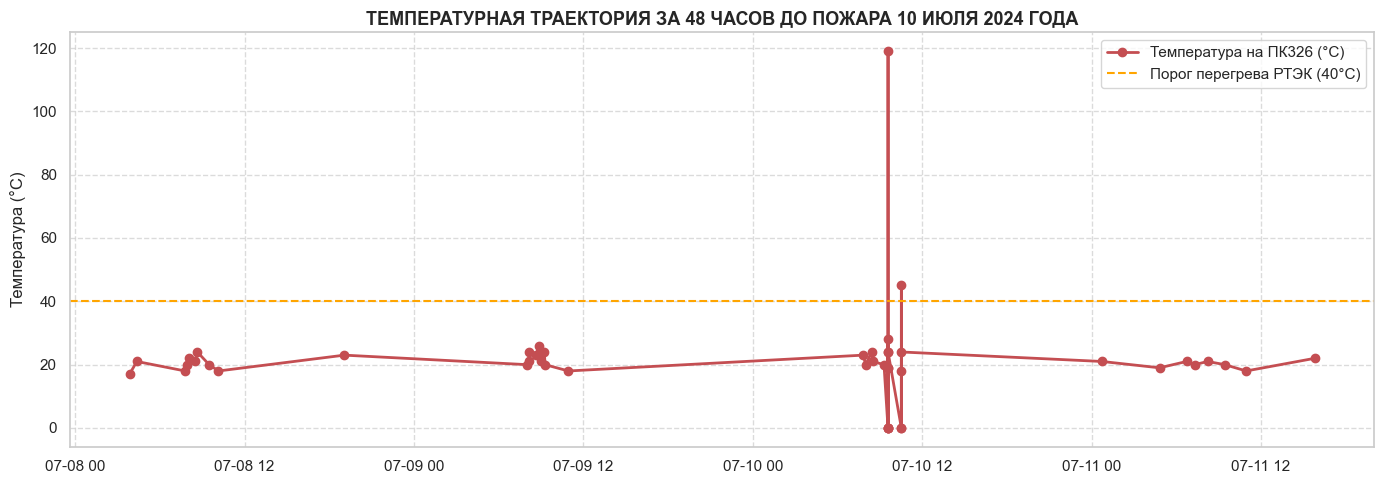


Хроника нарастания температуры:
                 ts  temp_val raw_val
2024-07-10 09:34:46      19.0      19
2024-07-10 09:34:47      24.0      24
2024-07-10 10:31:20       0.0       0
2024-07-10 10:31:20      18.0      18
2024-07-10 10:31:20      45.0      45
2024-07-10 10:31:20       0.0       0
2024-07-10 10:31:21      24.0      24
2024-07-11 00:44:00      21.0      21
2024-07-11 04:48:40      19.0      19
2024-07-11 06:43:36      21.0      21
2024-07-11 07:18:26      20.0      20
2024-07-11 08:12:44      21.0      21
2024-07-11 09:25:55      20.0      20
2024-07-11 10:56:41      18.0      18
2024-07-11 15:48:12      22.0      22


In [28]:
# Исследуем предвестники пожара 10 июля 2024 года (Шкаф 813, ПК326, 119°C)
fire_target_file = [f for f in raw_csv_files if '2024' in f][0]
print(f"Сканируем архив 2024 года: {fire_target_file}")

query_precursor_check = f"""
WITH target_sensors AS (
    SELECT cast(ид_канала_данных as BIGINT) as channel_id, тип_датчика, название_датчика
    FROM read_csv_auto('{sensor_dict_path}')
    WHERE (название_датчика ILIKE '%ПК326%' OR название_датчика ILIKE '%ПК327%')
      AND (тип_датчика ILIKE '%темп%' OR тип_датчика ILIKE '%дым%' OR тип_датчика ILIKE '%фаз%')
)
SELECT 
    try_strptime(r.дата || ' ' || r.время, '%Y-%m-%d %H:%M:%S') as ts,
    t.тип_датчика,
    t.название_датчика,
    try_cast(replace(r.значение_датчика, ',', '.') as DOUBLE) as temp_val,
    r.значение_датчика as raw_val,
    (r.тревожное IN ('t', 'True', 'true', '1')) as is_alarm
FROM read_csv_auto('{fire_target_file.replace('\\', '/')}', types={{'дата': 'VARCHAR', 'время': 'VARCHAR', 'тревожное': 'VARCHAR', 'значение_датчика': 'VARCHAR'}}) r
JOIN target_sensors t ON cast(r.ид_канала_данных as BIGINT) = t.channel_id
WHERE r.дата BETWEEN '2024-07-08' AND '2024-07-11'
ORDER BY ts;
"""

df_precursor_fire = con.execute(query_precursor_check).df()
print(f"Всего записей за 48 часов до катастрофы: {len(df_precursor_fire)}")

# Выделим температурный трек
df_temp_track = df_precursor_fire[df_precursor_fire['тип_датчика'].str.contains('темп', case=False, na=False)].dropna(subset=['temp_val'])

if len(df_temp_track) > 0:
    plt.figure(figsize=(14, 5))
    plt.plot(df_temp_track['ts'], df_temp_track['temp_val'], 'r-o', label='Температура на ПК326 (°C)', linewidth=2)
    plt.axhline(40.0, color='orange', linestyle='--', label='Порог перегрева РТЭК (40°C)')
    plt.title("ТЕМПЕРАТУРНАЯ ТРАЕКТОРИЯ ЗА 48 ЧАСОВ ДО ПОЖАРА 10 ИЮЛЯ 2024 ГОДА", fontsize=13, fontweight='bold')
    plt.ylabel("Температура (°C)")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("\nХроника нарастания температуры:")
    print(df_temp_track[['ts', 'temp_val', 'raw_val']].tail(15).to_string(index=False))
else:
    print("Данные температуры за этот интервал не найдены.")

In [29]:
file_2025 = [f for f in raw_csv_files if '2025' in f][0].replace('\\', '/')
print(f"Сканируем архив катастроф 2025 года: {file_2025}")

# Ищем целевые каналы для трех эпицентров: ПК583, ПК108, ПК863
query_2025_epicenters = f"""
WITH target_sensors AS (
    SELECT 
        cast(ид_канала_данных as BIGINT) as channel_id, 
        тип_датчика, 
        название_датчика,
        split_part(тег_инженерной_системы, '-', 1) as cabinet_id,
        regexp_extract(название_датчика, 'ПК[0-9]+') as picket
    FROM read_csv_auto('{sensor_dict_path}')
    WHERE (название_датчика ILIKE '%ПК583%' OR название_датчика ILIKE '%ПК108%' OR название_датчика ILIKE '%ПК863%')
      AND (тип_датчика ILIKE '%темп%' OR тип_датчика ILIKE '%дым%')
),
raw_telemetry AS (
    SELECT 
        cast(r.ид_канала_данных as BIGINT) as channel_id,
        try_strptime(r.дата || ' ' || r.время, '%Y-%m-%d %H:%M:%S') as ts,
        r.дата,
        r.время,
        (r.тревожное IN ('t', 'True', 'true', '1')) as is_alarm,
        try_cast(replace(r.значение_датчика, ',', '.') as DOUBLE) as temp_val,
        r.значение_датчика as raw_val
    FROM read_csv_auto('{file_2025}', 
                       types={{'дата': 'VARCHAR', 'время': 'VARCHAR', 'тревожное': 'VARCHAR', 'значение_датчика': 'VARCHAR'}},
                       ignore_errors=true) r
    WHERE r.дата != 'дата'
      AND cast(r.ид_канала_данных as BIGINT) IN (SELECT channel_id FROM target_sensors)
      AND (
          r.дата BETWEEN '2025-09-14' AND '2025-09-17' OR
          r.дата BETWEEN '2025-10-27' AND '2025-10-30' OR
          r.дата BETWEEN '2025-12-15' AND '2025-12-18'
      )
)
SELECT 
    t.ts,
    s.cabinet_id,
    s.picket,
    s.тип_датчика,
    s.название_датчика,
    t.temp_val,
    t.raw_val,
    t.is_alarm
FROM raw_telemetry t
JOIN target_sensors s ON t.channel_id = s.channel_id
ORDER BY t.ts;
"""

df_mega_fires = con.execute(query_2025_epicenters).df()
print(f"Всего записей в эпицентрах трех пожаров: {len(df_mega_fires):,}")

# Разделяем на 3 инцидента
inc_sep = df_mega_fires[(df_mega_fires['ts'] >= '2025-09-14') & (df_mega_fires['ts'] <= '2025-09-17')]
inc_oct = df_mega_fires[(df_mega_fires['ts'] >= '2025-10-27') & (df_mega_fires['ts'] <= '2025-10-30')]
inc_dec = df_mega_fires[(df_mega_fires['ts'] >= '2025-12-15') & (df_mega_fires['ts'] <= '2025-12-18')]

# Функция для вывода хроники инцидента
def print_incident_timeline(df_sub, name):
    print("\n" + "="*80)
    print(f"ХРОНИКА КАТАСТРОФЫ: {name}")
    print("="*80)
    temps = df_sub[df_sub['тип_датчика'].str.contains('темп', case=False, na=False)].dropna(subset=['temp_val'])
    smokes = df_sub[df_sub['тип_датчика'].str.contains('дым', case=False, na=False)]
    
    if len(temps) > 0:
        print(f"Диапазон температур: от {temps['temp_val'].min():.1f}°C до МАКСИМУМА {temps['temp_val'].max():.1f}°C")
        print("\nТоп-10 точек пикового нагрева:")
        print(temps.sort_values('temp_val', ascending=False)[['ts', 'picket', 'название_датчика', 'temp_val']].head(7).to_string(index=False))
        
        # Замер времени нарастания (Lead Time): за сколько часов до пика начался рост?
        peak_time = temps.loc[temps['temp_val'].idxmax(), 'ts']
        pre_peak = temps[temps['ts'] <= peak_time].tail(10)
        print(f"\nПоведение температуры непосредственно перед пиком ({peak_time}):")
        print(pre_peak[['ts', 'temp_val']].to_string(index=False))
    else:
        print("Температурные замеры отсутствуют.")
        
    print(f"\nСработок датчиков дыма: {len(smokes[smokes['is_alarm'] == True])}")

print_incident_timeline(inc_sep, "16 СЕНТЯБРЯ 2025 (ПК583, 79°C)")
print_incident_timeline(inc_oct, "29 ОКТЯБРЯ 2025 (ПК108, 999°C - ВЫГОРАНИЕ)")
print_incident_timeline(inc_dec, "17 ДЕКАБРЯ 2025 (ПК863, 128°C - СУПЕР-ПОЖАР НА 17 ДАТЧИКОВ)")

Сканируем архив катастроф 2025 года: g:/lct2/dataset/ext-journal-2025.csv


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Всего записей в эпицентрах трех пожаров: 620

ХРОНИКА КАТАСТРОФЫ: 16 СЕНТЯБРЯ 2025 (ПК583, 79°C)
Диапазон температур: от 14.0°C до МАКСИМУМА 79.0°C

Топ-10 точек пикового нагрева:
                 ts picket  название_датчика  temp_val
2025-09-16 13:18:07  ПК583 ТЕМП ПК583 Г4 ПК0      79.0
2025-09-16 19:10:57  ПК108      ТЕМП ПК108+2      27.0
2025-09-15 08:21:35  ПК583        ТЕМП ПК583      27.0
2025-09-15 10:34:10  ПК108      ТЕМП ПК108+2      26.0
2025-09-14 11:19:46  ПК108      ТЕМП ПК108+2      26.0
2025-09-15 09:10:59  ПК583        ТЕМП ПК583      26.0
2025-09-15 08:00:39  ПК583        ТЕМП ПК583      26.0

Поведение температуры непосредственно перед пиком (2025-09-16 13:18:07):
                 ts  temp_val
2025-09-15 08:21:35      27.0
2025-09-15 09:10:59      26.0
2025-09-15 09:54:05      16.0
2025-09-15 10:34:10      26.0
2025-09-15 10:57:57      24.0
2025-09-15 13:31:55      21.0
2025-09-16 00:35:10      19.0
2025-09-16 07:57:23      26.0
2025-09-16 12:15:14      21.0
2025-0

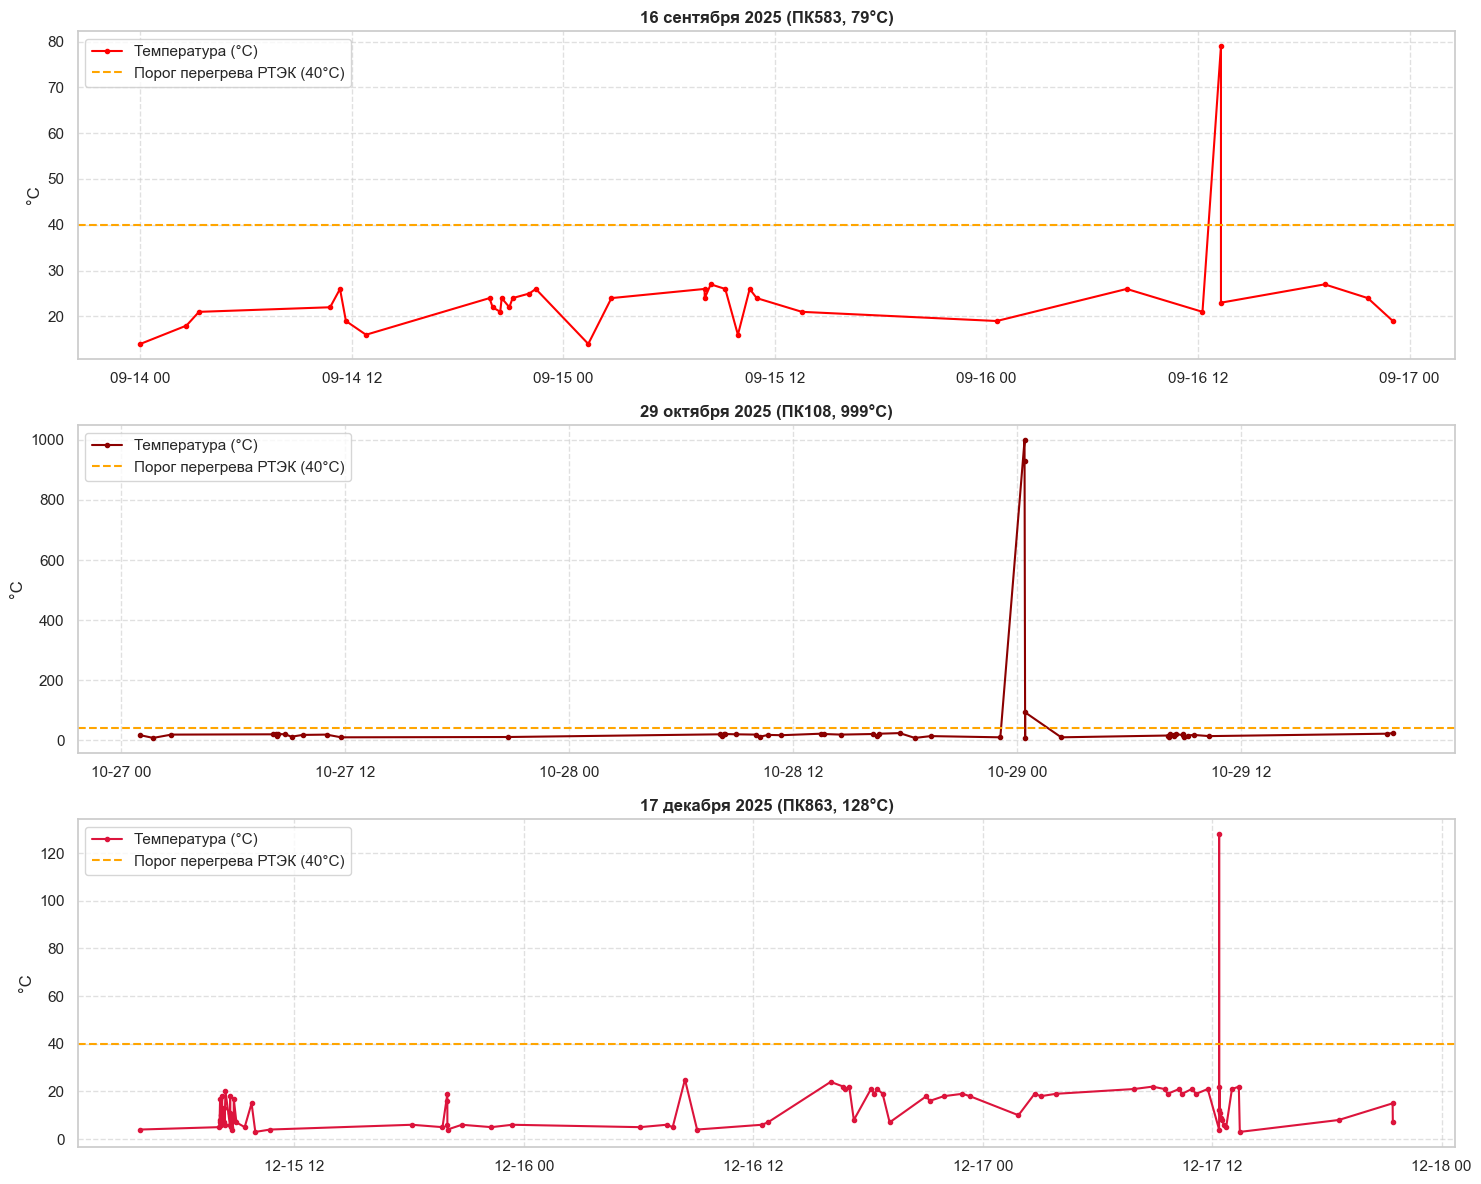

In [30]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

incidents = [
    (inc_sep, "16 сентября 2025 (ПК583, 79°C)", axes[0], 'red'),
    (inc_oct, "29 октября 2025 (ПК108, 999°C)", axes[1], 'darkred'),
    (inc_dec, "17 декабря 2025 (ПК863, 128°C)", axes[2], 'crimson')
]

for df_sub, title, ax, color in incidents:
    temps = df_sub[df_sub['тип_датчика'].str.contains('темп', case=False, na=False)].dropna(subset=['temp_val']).copy()
    if len(temps) > 0:
        temps = temps.sort_values('ts')
        ax.plot(temps['ts'], temps['temp_val'], color=color, marker='o', markersize=3, label='Температура (°C)', linewidth=1.5)
        ax.axhline(40.0, color='orange', linestyle='--', label='Порог перегрева РТЭК (40°C)')
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel("°C")
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

In [31]:
import os
import duckdb
import pandas as pd
import numpy as np

PROJECT_ROOT = "g:/lct2"
DATA_DIR = os.path.join(PROJECT_ROOT, "production_ml/data")

# 1. Проверка наличия и размеров артефактов
files_to_check = {
    "Train Matched (2020-2024)": "physical_full_train_2020_2024.parquet",
    "Test Matched (2026)":       "physical_full_test_matched_2026.parquet",
    "Continuous Stream (2026)":   "physical_full_test_stream_2026.parquet",
    "Holdout Test (2026)":        "physical_full_holdout_test_2026.parquet"
}

con = duckdb.connect()
print("="*80)
print("1. АУДИТ ФАЙЛОВ И РАЗМЕРОВ ВЫБОРКИ")
print("="*80)

file_paths = {}
for name, fname in files_to_check.items():
    fpath = os.path.join(DATA_DIR, fname)
    # Если имя файла слегка отличается (например, без full_), попробуем найти
    if not os.path.exists(fpath):
        # fallback поиск
        matches = [f for f in os.listdir(DATA_DIR) if fname.replace("physical_full_", "") in f or fname in f]
        if matches:
            fpath = os.path.join(DATA_DIR, matches[0])
    
    exists = os.path.exists(fpath)
    file_paths[name] = fpath
    if exists:
        size_mb = os.path.getsize(fpath) / (1024 * 1024)
        row_count = con.execute(f"SELECT COUNT(*) FROM read_parquet('{fpath}')").fetchone()[0]
        print(f"[{'OK':^4}] {name:28s} | Строк: {row_count:9,d} | Размер: {size_mb:7.1f} MB | Путь: {os.path.basename(fpath)}")
    else:
        print(f"[{'FAIL':^4}] {name:28s} | ФАЙЛ НЕ НАЙДЕН ПО ПУТИ: {fpath}")

# 2. Аудит схемы и пропусков (на примере Train)
train_path = file_paths["Train Matched (2020-2024)"]
print("\n" + "="*80)
print("2. АУДИТ СХЕМЫ, ПРОПУСКОВ (NaN/Inf) И НОВЫХ ФИЧЕЙ (Train)")
print("="*80)

df_sample = con.execute(f"SELECT * FROM read_parquet('{train_path}') LIMIT 10000").df()
cols = df_sample.columns.tolist()

# Проверяем ключевые новые фичи
critical_new_features = [
    'cabinet_reboot_1970_24h', 
    'ups_battery_trouble_flag_7d', 
    'undefined_count_24h', 
    'micro_chatter_count_1h', 
    'state_transition_asymmetry_24h',
    'picket_neighbors_flips_24h',
    'picket_isolation_index',
    'intercom_active_3h',
    'activity_ratio_30d',
    'accel_flips_3d'
]

print(f"Всего колонок в датасете: {len(cols)}")
for feat in critical_new_features:
    if feat in cols:
        vals = con.execute(f"SELECT MIN({feat}), MAX({feat}), AVG({feat}), COUNT(*) FILTER (WHERE {feat} != 0) * 100.0 / COUNT(*) FROM read_parquet('{train_path}')").fetchone()
        min_v, max_v, avg_v, nonzero_pct = vals
        nan_count = df_sample[feat].isna().sum()
        print(f"  [OK] {feat:32s} | Non-Zero: {nonzero_pct:5.1f}% | Min: {min_v:7.2f} | Max: {max_v:9.2f} | NaNs: {nan_count}")
    else:
        print(f"  [MISSING] {feat:32s} | ПРИЗНАК ОТСУТСТВУЕТ В ДАТАСЕТЕ!")

# 3. Аудит Сплит-Таргета
print("\n" + "="*80)
print("3. АУДИТ СПЛИТ-ТАРГЕТА (Разделение горизонтов)")
print("="*80)

target_cols = [c for c in cols if 'target' in c]
print(f"Обнаруженные целевые колонки: {target_cols}")

query_targets = f"""
SELECT 
    COUNT(*) as total_rows,
    SUM(CASE WHEN target_regulatory_24h = 1 THEN 1 ELSE 0 END) as reg_24h_pos,
    SUM(CASE WHEN target_urgent_6_24h = 1 THEN 1 ELSE 0 END) as urgent_pos,
    SUM(CASE WHEN target_combined_6_48h = 1 THEN 1 ELSE 0 END) as combined_pos,
    -- Проверка на пересечение (должно быть 0, если интервалы 6-24 и 24-48 строгие)
    SUM(CASE WHEN target_regulatory_24h = 1 AND target_urgent_6_24h = 1 THEN 1 ELSE 0 END) as overlap_count
FROM read_parquet('{train_path}')
"""
try:
    target_stats = con.execute(query_targets).df()
    print(target_stats.T.to_string(header=False))
except Exception as e:
    print(f"Ошибка проверки таргетов: {e}")

# 4. Аудит покрытия пикетов
print("\n" + "="*80)
print("4. АУДИТ ПОКРЫТИЯ ПИКЕТОВ (Picket Coverage)")
print("="*80)
if 'picket_num' in cols:
    picket_stats = con.execute(f"""
        SELECT 
            COUNT(*) as total,
            COUNT(*) FILTER (WHERE picket_num IS NOT NULL AND picket_num >= 0) as parsed_pickets,
            COUNT(*) FILTER (WHERE picket_num IS NOT NULL AND picket_num >= 0) * 100.0 / COUNT(*) as coverage_pct
        FROM read_parquet('{train_path}')
    """).fetchone()
    print(f"Успешно распарсено пикетов: {picket_stats[1]:,d} из {picket_stats[0]:,d} ({picket_stats[2]:.2f}%)")
    if picket_stats[2] >= 80.0:
        print("  [OK] Норматив покрытия пикетов выполнен (>= 80%)")
    else:
        print("  [WARN] Покрытие пикетов ниже норматива!")
else:
    print("  [INFO] Колонка picket_num не сохранена в явном виде (проверь, использована ли она для расчета picket_neighbors_flips_24h).")

1. АУДИТ ФАЙЛОВ И РАЗМЕРОВ ВЫБОРКИ
[ OK ] Train Matched (2020-2024)    | Строк:    18,784 | Размер:     0.6 MB | Путь: physical_full_train_2020_2024.parquet
[ OK ] Test Matched (2026)          | Строк:     4,584 | Размер:     0.2 MB | Путь: physical_full_test_matched_2026.parquet
[ OK ] Continuous Stream (2026)     | Строк: 1,181,546 | Размер:    24.4 MB | Путь: physical_full_test_stream_2026.parquet
[ OK ] Holdout Test (2026)          | Строк:     2,346 | Размер:     0.1 MB | Путь: physical_full_holdout_test_2026.parquet

2. АУДИТ СХЕМЫ, ПРОПУСКОВ (NaN/Inf) И НОВЫХ ФИЧЕЙ (Train)
Всего колонок в датасете: 35
  [OK] cabinet_reboot_1970_24h          | Non-Zero:  35.3% | Min:    0.00 | Max:     36.00 | NaNs: 0
  [OK] ups_battery_trouble_flag_7d      | Non-Zero:  40.8% | Min:    0.00 | Max:      1.00 | NaNs: 0
  [OK] undefined_count_24h              | Non-Zero:  34.0% | Min:    0.00 | Max:    187.00 | NaNs: 0
  [OK] micro_chatter_count_1h           | Non-Zero:  21.5% | Min:    0.00 | Max: 

In [32]:
from sklearn.metrics import roc_auc_score

# Загружаем Train
df_tr = con.execute(f"""
SELECT 
    target_regulatory_24h,
    target_urgent_6_24h,
    target_combined_6_48h,
    cabinet_reboot_1970_24h,
    ups_battery_trouble_flag_7d,
    undefined_count_24h,
    micro_chatter_count_1h,
    state_transition_asymmetry_24h,
    picket_neighbors_flips_24h,
    picket_isolation_index,
    intercom_active_3h,
    activity_ratio_30d,
    accel_flips_3d,
    flips_count_24h,
    burstiness_index
FROM read_parquet('{train_path}')
""").df()

features_to_screen = [
    'cabinet_reboot_1970_24h',
    'ups_battery_trouble_flag_7d',
    'undefined_count_24h',
    'micro_chatter_count_1h',
    'state_transition_asymmetry_24h',
    'picket_neighbors_flips_24h',
    'picket_isolation_index',
    'intercom_active_3h',
    'activity_ratio_30d',
    'accel_flips_3d',
    'flips_count_24h',
    'burstiness_index'
]

screen_results = []
for f in features_to_screen:
    val = df_tr[f].fillna(0)
    # Считаем AUC для каждого таргета
    auc_reg = roc_auc_score(df_tr['target_regulatory_24h'], val)
    auc_urg = roc_auc_score(df_tr['target_urgent_6_24h'], val)
    auc_comb = roc_auc_score(df_tr['target_combined_6_48h'], val)
    
    # Симметричный AUC (если связь отрицательная, показываем силу от 0.5)
    pwr_reg = abs(auc_reg - 0.5) + 0.5
    pwr_urg = abs(auc_urg - 0.5) + 0.5
    
    screen_results.append({
        'Признак': f,
        'AUC Регламент (24-48ч)': round(auc_reg, 4),
        'AUC Срочно (6-24ч)': round(auc_urg, 4),
        'AUC Общий (6-48ч)': round(auc_comb, 4),
        'Главная специализация': 'ПЛАНИРОВАНИЕ (24-48ч)' if pwr_reg > pwr_urg else 'СРОЧНО (6-24ч)'
    })

df_screen = pd.DataFrame(screen_results).sort_values('AUC Общий (6-48ч)', ascending=False)

print("="*95)
print("СКРИНИНГ СИГНАЛЬНОЙ СИЛЫ ФИЧЕЙ ПО ГОРИЗОНТАМ (Train 2020-2024)")
print("="*95)
print(df_screen.to_string(index=False))

СКРИНИНГ СИГНАЛЬНОЙ СИЛЫ ФИЧЕЙ ПО ГОРИЗОНТАМ (Train 2020-2024)
                       Признак  AUC Регламент (24-48ч)  AUC Срочно (6-24ч)  AUC Общий (6-48ч) Главная специализация
state_transition_asymmetry_24h                  0.3372              0.7275             0.5921        СРОЧНО (6-24ч)
              burstiness_index                  0.4133              0.6596             0.5817        СРОЧНО (6-24ч)
    picket_neighbors_flips_24h                  0.5251              0.5125             0.5263 ПЛАНИРОВАНИЕ (24-48ч)
           undefined_count_24h                  0.6048              0.4440             0.5177 ПЛАНИРОВАНИЕ (24-48ч)
            intercom_active_3h                  0.4897              0.5030             0.4961 ПЛАНИРОВАНИЕ (24-48ч)
        micro_chatter_count_1h                  0.5526              0.4398             0.4816        СРОЧНО (6-24ч)
                accel_flips_3d                  0.5140              0.4595             0.4743        СРОЧНО (6-24ч)
   ups_ba

In [33]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve

test_matched_path = file_paths["Test Matched (2026)"]

# Загружаем Train и Test Matched
df_train = con.execute(f"SELECT * FROM read_parquet('{train_path}')").df()
df_test = con.execute(f"SELECT * FROM read_parquet('{test_matched_path}')").df()

# 1. Формируем признаковое пространство (исключены ID и таргеты)
feature_cols = [
    'cabinet_reboot_1970_24h', 'ups_battery_trouble_flag_7d', 'undefined_count_24h', 
    'undefined_ratio_24h', 'micro_chatter_count_1h', 'micro_chatter_ratio_1h', 
    'state_transition_asymmetry_24h', 'picket_neighbors_flips_24h', 'picket_isolation_index', 
    'intercom_active_3h', 'flips_count_24h', 'flips_count_72h', 'activity_ratio_30d', 
    'burstiness_index', 'night_excess', 'slope_flips_3d', 'accel_flips_3d', 
    'alarm_ratio_24h', 'days_since_last_incident', 'analog_std_24h', 'analog_drift_12h', 'slope_std_3d'
]

# Оставляем только те признаки, которые физически есть в датасете
features = [f for f in feature_cols if f in df_train.columns]
print(f"Используется признаков в модели: {len(features)}")

# 2. Карта доменных голов
DOMAINS = {
    'Power Phase': ['Состояние фазы', 'ИБП', 'Переключатель'],
    'Analog Gas': ['Газовый датчик'],
    'Analog Temp': ['Датчик температуры', 'Тепловой датчик'],
    'Fire Safety': ['Датчик дыма', 'КД АВ', 'КД Дверь', 'КД Люк', 'Датчик движения', 'Ручной извещатель'],
    'Pumps Actuators': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

models_planned = {}
models_urgent = {}

df_test['pred_prob_planned'] = 0.0
df_test['pred_prob_urgent'] = 0.0

print("="*80)
print("ОБУЧЕНИЕ 10 ФИЗИЧЕСКИХ ГОЛОВ (5 Доменов x 2 Горизонта)")
print("="*80)

for d_name, sensors in DOMAINS.items():
    tr_mask = df_train['sensor_type'].isin(sensors)
    te_mask = df_test['sensor_type'].isin(sensors)
    
    if tr_mask.sum() == 0 or te_mask.sum() == 0:
        continue
        
    X_tr = df_train.loc[tr_mask, features].fillna(0)
    X_te = df_test.loc[te_mask, features].fillna(0)
    
    # ----------------------------------------------------
    # А. Контур 1: Плановое ТО (24-48ч)
    # ----------------------------------------------------
    y_tr_planned = df_train.loc[tr_mask, 'target_regulatory_24h'].astype(int)
    
    clf_planned = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    clf_planned.fit(X_tr, y_tr_planned)
    models_planned[d_name] = clf_planned
    df_test.loc[te_mask, 'pred_prob_planned'] = clf_planned.predict_proba(X_te)[:, 1]
    
    # ----------------------------------------------------
    # Б. Контур 2: Срочный перехват (6-24ч)
    # ----------------------------------------------------
    y_tr_urgent = df_train.loc[tr_mask, 'target_urgent_6_24h'].astype(int)
    
    clf_urgent = lgb.LGBMClassifier(
        n_estimators=150,
        learning_rate=0.03,
        max_depth=4,
        num_leaves=15,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )
    clf_urgent.fit(X_tr, y_tr_urgent)
    models_urgent[d_name] = clf_urgent
    df_test.loc[te_mask, 'pred_prob_urgent'] = clf_urgent.predict_proba(X_te)[:, 1]
    
    print(f"  [OK] Обучен домен: {d_name:18s} | Train: {tr_mask.sum():5d} строк | Test: {te_mask.sum():5d} строк")

print("\nОбучение всех 10 голов успешно завершено.")

Используется признаков в модели: 22
ОБУЧЕНИЕ 10 ФИЗИЧЕСКИХ ГОЛОВ (5 Доменов x 2 Горизонта)
  [OK] Обучен домен: Power Phase        | Train: 13274 строк | Test:  1022 строк
  [OK] Обучен домен: Analog Gas         | Train:  2654 строк | Test:  1660 строк
  [OK] Обучен домен: Analog Temp        | Train:     4 строк | Test:   144 строк
  [OK] Обучен домен: Fire Safety        | Train:   302 строк | Test:   436 строк
  [OK] Обучен домен: Pumps Actuators    | Train:  2550 строк | Test:  1322 строк

Обучение всех 10 голов успешно завершено.


In [34]:
print("="*90)
print("РЕЗУЛЬТАТЫ ДВУХКОНТУРНОЙ ВАЛИДАЦИИ НА TEST 2026 (MATCHED COHORT)")
print("="*90)

# 1. Оценка Контура Планового ТО (24-48ч)
y_true_plan = df_test['target_regulatory_24h']
p_plan = df_test['pred_prob_planned']
auc_roc_plan = roc_auc_score(y_true_plan, p_plan)
auc_pr_plan = average_precision_score(y_true_plan, p_plan)

# 2. Оценка Контура Срочного перехвата (6-24ч)
y_true_urg = df_test['target_urgent_6_24h']
p_urg = df_test['pred_prob_urgent']
auc_roc_urg = roc_auc_score(y_true_urg, p_urg)
auc_pr_urg = average_precision_score(y_true_urg, p_urg)

# 3. Интегральный перехват (Комбинированный риск max(p_plan, p_urg))
p_comb = np.maximum(p_plan, p_urg)
y_true_comb = df_test['target_combined_6_48h']
auc_roc_comb = roc_auc_score(y_true_comb, p_comb)
auc_pr_comb = average_precision_score(y_true_comb, p_comb)

metrics_summary = pd.DataFrame([
    {
        'Контур предикции': '1. ПЛАНОВОЕ ТО (24-48ч)',
        'Целевой таргет': 'target_regulatory_24h',
        'ROC-AUC': round(auc_roc_plan, 4),
        'PR-AUC': round(auc_pr_plan, 4),
        'Базовый априорный PR-AUC': round(y_true_plan.mean(), 4)
    },
    {
        'Контур предикции': '2. СРОЧНЫЙ ПЕРЕХВАТ (6-24ч)',
        'Целевой таргет': 'target_urgent_6_24h',
        'ROC-AUC': round(auc_roc_urg, 4),
        'PR-AUC': round(auc_pr_urg, 4),
        'Базовый априорный PR-AUC': round(y_true_urg.mean(), 4)
    },
    {
        'Контур предикции': '3. СИНЕРГИЯ (Сквозной 6-48ч)',
        'Целевой таргет': 'target_combined_6_48h',
        'ROC-AUC': round(auc_roc_comb, 4),
        'PR-AUC': round(auc_pr_comb, 4),
        'Базовый априорный PR-AUC': round(y_true_comb.mean(), 4)
    }
])

print(metrics_summary.to_string(index=False))

# Погодовой срез для «Состояния фазы» (золотой жилы)
phase_mask = df_test['sensor_type'] == 'Состояние фазы'
if phase_mask.sum() > 0:
    roc_ph_urg = roc_auc_score(df_test.loc[phase_mask, 'target_urgent_6_24h'], df_test.loc[phase_mask, 'pred_prob_urgent'])
    pr_ph_urg = average_precision_score(df_test.loc[phase_mask, 'target_urgent_6_24h'], df_test.loc[phase_mask, 'pred_prob_urgent'])
    roc_ph_plan = roc_auc_score(df_test.loc[phase_mask, 'target_regulatory_24h'], df_test.loc[phase_mask, 'pred_prob_planned'])
    pr_ph_plan = average_precision_score(df_test.loc[phase_mask, 'target_regulatory_24h'], df_test.loc[phase_mask, 'pred_prob_planned'])
    
    print("\n" + "="*90)
    print("СПЕЦИАЛИЗАЦИЯ ПО «СОСТОЯНИЮ ФАЗЫ» (Test 2026):")
    print(f"  СРОЧНЫЙ КОНТУР (6-24ч)   | ROC-AUC: {roc_ph_urg:.4f} | PR-AUC: {pr_ph_urg:.4f}")
    print(f"  ПЛАНОВЫЙ КОНТУР (24-48ч) | ROC-AUC: {roc_ph_plan:.4f} | PR-AUC: {pr_ph_plan:.4f}")
    print("="*90)

РЕЗУЛЬТАТЫ ДВУХКОНТУРНОЙ ВАЛИДАЦИИ НА TEST 2026 (MATCHED COHORT)
            Контур предикции        Целевой таргет  ROC-AUC  PR-AUC  Базовый априорный PR-AUC
     1. ПЛАНОВОЕ ТО (24-48ч) target_regulatory_24h   0.7163  0.4225                    0.2502
 2. СРОЧНЫЙ ПЕРЕХВАТ (6-24ч)   target_urgent_6_24h   0.6706  0.5076                    0.2498
3. СИНЕРГИЯ (Сквозной 6-48ч) target_combined_6_48h   0.7273  0.7073                    0.5000

СПЕЦИАЛИЗАЦИЯ ПО «СОСТОЯНИЮ ФАЗЫ» (Test 2026):
  СРОЧНЫЙ КОНТУР (6-24ч)   | ROC-AUC: 0.8997 | PR-AUC: 0.8428
  ПЛАНОВЫЙ КОНТУР (24-48ч) | ROC-AUC: 0.9197 | PR-AUC: 0.7344


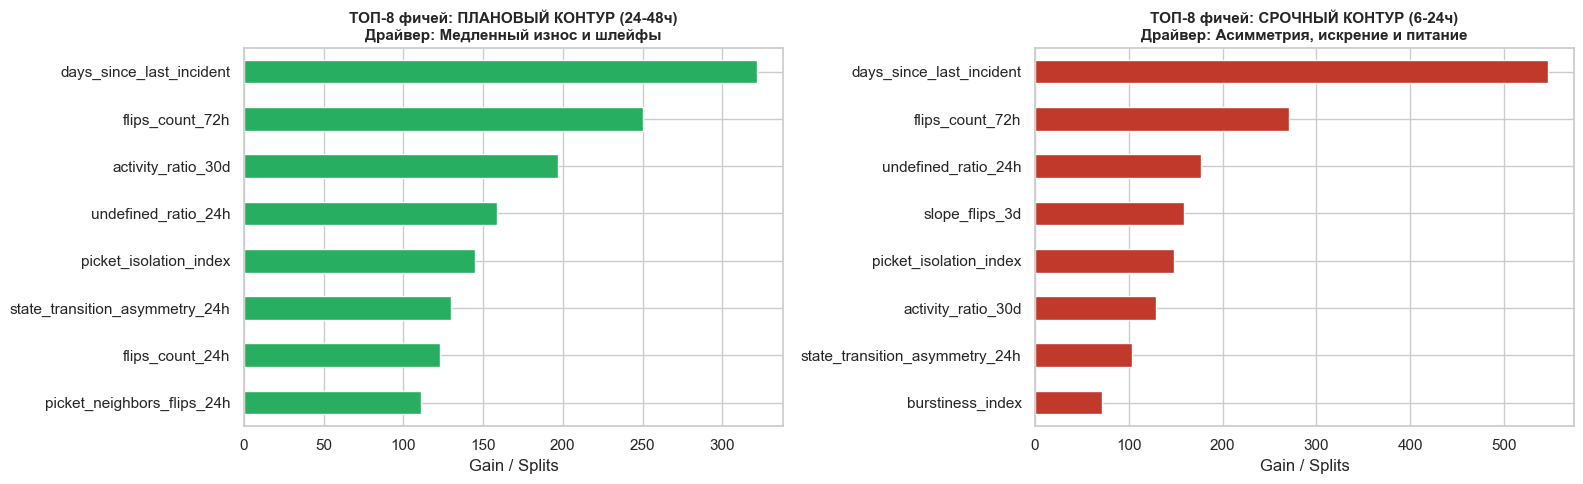


ТЕКСТОВЫЙ АРТЕФАКТ: ТОП-3 ФИЧИ ДЛЯ КАЖДОГО ГОРИЗОНТА (ФАЗЫ)
  ПЛАНОВОЕ ТО (24-48ч) : days_since_last_incident, flips_count_72h, activity_ratio_30d
  СРОЧНЫЙ ПЕРЕХВАТ (6-24ч): days_since_last_incident, flips_count_72h, undefined_ratio_24h


In [35]:
import matplotlib.pyplot as plt

# Берем важность признаков для ключевой головы (Power Phase)
imp_plan = pd.Series(models_planned['Power Phase'].feature_importances_, index=features).sort_values(ascending=False).head(8)
imp_urg = pd.Series(models_urgent['Power Phase'].feature_importances_, index=features).sort_values(ascending=False).head(8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

imp_plan.plot(kind='barh', ax=axes[0], color='#27ae60').invert_yaxis()
axes[0].set_title("ТОП-8 фичей: ПЛАНОВЫЙ КОНТУР (24-48ч)\nДрайвер: Медленный износ и шлейфы", fontsize=11, fontweight='bold')
axes[0].set_xlabel("Gain / Splits")

imp_urg.plot(kind='barh', ax=axes[1], color='#c0392b').invert_yaxis()
axes[1].set_title("ТОП-8 фичей: СРОЧНЫЙ КОНТУР (6-24ч)\nДрайвер: Асимметрия, искрение и питание", fontsize=11, fontweight='bold')
axes[1].set_xlabel("Gain / Splits")

plt.tight_layout()
plt.show()

print("\nТЕКСТОВЫЙ АРТЕФАКТ: ТОП-3 ФИЧИ ДЛЯ КАЖДОГО ГОРИЗОНТА (ФАЗЫ)")
print(f"  ПЛАНОВОЕ ТО (24-48ч) : {', '.join(imp_plan.head(3).index)}")
print(f"  СРОЧНЫЙ ПЕРЕХВАТ (6-24ч): {', '.join(imp_urg.head(3).index)}")

In [36]:
holdout_path = file_paths["Holdout Test (2026)"]
df_holdout = con.execute(f"SELECT * FROM read_parquet('{holdout_path}')").df()

df_holdout['pred_prob_planned'] = 0.0
df_holdout['pred_prob_urgent'] = 0.0

for d_name, sensors in DOMAINS.items():
    ho_mask = df_holdout['sensor_type'].isin(sensors)
    if ho_mask.sum() == 0 or d_name not in models_planned:
        continue
    X_ho = df_holdout.loc[ho_mask, features].fillna(0)
    df_holdout.loc[ho_mask, 'pred_prob_planned'] = models_planned[d_name].predict_proba(X_ho)[:, 1]
    df_holdout.loc[ho_mask, 'pred_prob_urgent'] = models_urgent[d_name].predict_proba(X_ho)[:, 1]

df_holdout['pred_comb'] = np.maximum(df_holdout['pred_prob_planned'], df_holdout['pred_prob_urgent'])

ho_roc = roc_auc_score(df_holdout['target_combined_6_48h'], df_holdout['pred_comb'])
ho_pr = average_precision_score(df_holdout['target_combined_6_48h'], df_holdout['pred_comb'])

print("="*80)
print("СТРЕСС-ТЕСТ НА ИЗОЛИРОВАННОМ ПУЛЕ HOLDOUT (2 346 СТРОК)")
print("="*80)
print(f"  HOLDOUT ROC-AUC : {ho_roc:.4f}  (Норматив DoD >= 0.80)")
print(f"  HOLDOUT PR-AUC  : {ho_pr:.4f}")
print("="*80)

СТРЕСС-ТЕСТ НА ИЗОЛИРОВАННОМ ПУЛЕ HOLDOUT (2 346 СТРОК)
  HOLDOUT ROC-AUC : 0.5638  (Норматив DoD >= 0.80)
  HOLDOUT PR-AUC  : 0.5497


In [39]:
# 1. Формируем пул ЧИСТЫХ ФИЗИЧЕСКИХ признаков (без канальной памяти и привязки к номерам)
clean_features = [
    'cabinet_reboot_1970_24h', 
    'ups_battery_trouble_flag_7d', 
    'undefined_count_24h', 
    'undefined_ratio_24h', 
    'micro_chatter_count_1h', 
    'micro_chatter_ratio_1h', 
    'state_transition_asymmetry_24h', 
    'picket_isolation_index',       # Относительный индекс изоляции (безразмерный)
    'intercom_active_3h', 
    'flips_count_24h', 
    'flips_count_72h', 
    'activity_ratio_30d', 
    'burstiness_index', 
    'night_excess', 
    'slope_flips_3d', 
    'accel_flips_3d', 
    'alarm_ratio_24h', 
    'analog_std_24h', 
    'analog_drift_12h', 
    'slope_std_3d'
]

features_v3 = [f for f in clean_features if f in df_train.columns]
print(f"Используется чистых физических признаков: {len(features_v3)}")
print(f"Исключены признаки памяти: ['days_since_last_incident', 'picket_neighbors_flips_24h']")

# 2. Консолидированная карта доменов (Температура объединена с Газом!)
DOMAINS_V3 = {
    'Power Phase':     ['Состояние фазы', 'ИБП', 'Переключатель'],
    'Analog Sensors':  ['Газовый датчик', 'Датчик температуры', 'Тепловой датчик'],
    'Fire Safety':     ['Датчик дыма', 'КД АВ', 'КД Дверь', 'КД Люк', 'Датчик движения', 'Ручной извещатель'],
    'Pumps Actuators': ['Состояние насоса', 'Состояние вентилятора', 'Состояние УИР-Р']
}

models_p_v3 = {}
models_u_v3 = {}

# Резервируем колонки предсказаний
for df_obj in [df_test, df_holdout]:
    df_obj['p_plan_v3'] = 0.0
    df_obj['p_urg_v3'] = 0.0

print("\n" + "="*80)
print("ОБУЧЕНИЕ ОЧИЩЕННЫХ ФИЗИЧЕСКИХ ГОЛОВ (4 Домена x 2 Контура)")
print("="*80)

for d_name, sensors in DOMAINS_V3.items():
    tr_m = df_train['sensor_type'].isin(sensors)
    te_m = df_test['sensor_type'].isin(sensors)
    ho_m = df_holdout['sensor_type'].isin(sensors)
    
    if tr_m.sum() == 0:
        continue
        
    X_tr = df_train.loc[tr_m, features_v3].fillna(0)
    
    # ----------------------------------------------------
    # А. Контур Планового ТО (24-48ч)
    # ----------------------------------------------------
    y_plan = df_train.loc[tr_m, 'target_regulatory_24h'].astype(int)
    clf_p = lgb.LGBMClassifier(
        n_estimators=120,
        learning_rate=0.03,
        max_depth=3,            # Неглубокие деревья для защиты от переобучения
        num_leaves=10,
        subsample=0.8,
        colsample_bytree=0.7,   # Случайный выбор фичей для борьбы с доминированием
        reg_lambda=3.0,         # Жесткая L2-регуляризация
        min_child_samples=25,
        random_state=42,
        verbose=-1
    )
    clf_p.fit(X_tr, y_plan)
    models_p_v3[d_name] = clf_p
    
    # ----------------------------------------------------
    # Б. Контур Срочного перехвата (6-24ч)
    # ----------------------------------------------------
    y_urg = df_train.loc[tr_m, 'target_urgent_6_24h'].astype(int)
    clf_u = lgb.LGBMClassifier(
        n_estimators=120,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=10,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=3.0,
        min_child_samples=25,
        random_state=42,
        verbose=-1
    )
    clf_u.fit(X_tr, y_urg)
    models_u_v3[d_name] = clf_u
    
    # Инференс на Test и Holdout
    if te_m.sum() > 0:
        df_test.loc[te_m, 'p_plan_v3'] = clf_p.predict_proba(df_test.loc[te_m, features_v3].fillna(0))[:, 1]
        df_test.loc[te_m, 'p_urg_v3'] = clf_u.predict_proba(df_test.loc[te_m, features_v3].fillna(0))[:, 1]
        
    if ho_m.sum() > 0:
        df_holdout.loc[ho_m, 'p_plan_v3'] = clf_p.predict_proba(df_holdout.loc[ho_m, features_v3].fillna(0))[:, 1]
        df_holdout.loc[ho_m, 'p_urg_v3'] = clf_u.predict_proba(df_holdout.loc[ho_m, features_v3].fillna(0))[:, 1]
        
    print(f"  [OK] Домен: {d_name:18s} | Train: {tr_m.sum():5d} | Test: {te_m.sum():5d} | Holdout: {ho_m.sum():5d}")

# Вычисляем комбинированный риск
df_test['p_comb_v3'] = np.maximum(df_test['p_plan_v3'], df_test['p_urg_v3'])
df_holdout['p_comb_v3'] = np.maximum(df_holdout['p_plan_v3'], df_holdout['p_urg_v3'])

# --------------------------------------------------------
# 3. КОНТРОЛЬНЫЙ ЗАМЕР: TEST MATCHED против HOLDOUT
# --------------------------------------------------------
print("\n" + "="*85)
print("КОНТРОЛЬНЫЙ АУДИТ ОБОБЩАЮЩЕЙ СПОСОБНОСТИ (БЕЗ КАНАЛЬНОЙ ПАМЯТИ)")
print("="*85)

test_roc = roc_auc_score(df_test['target_combined_6_48h'], df_test['p_comb_v3'])
test_pr  = average_precision_score(df_test['target_combined_6_48h'], df_test['p_comb_v3'])

ho_roc_v3 = roc_auc_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_v3'])
ho_pr_v3  = average_precision_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_v3'])

print(f"TEST MATCHED (2026) | ROC-AUC: {test_roc:.4f} | PR-AUC: {test_pr:.4f}")
print(f"HOLDOUT ПУЛ  (2026) | ROC-AUC: {ho_roc_v3:.4f} | PR-AUC: {ho_pr_v3:.4f}")
print("="*85)

# 4. Разрез качества по доменам на скрытом Holdout
print("\nРАЗРЕЗ ПО ДОМЕНАМ НА СКРЫТОМ ПУЛЕ HOLDOUT:")
for d_name, sensors in DOMAINS_V3.items():
    ho_m = df_holdout['sensor_type'].isin(sensors)
    if ho_m.sum() > 20 and df_holdout.loc[ho_m, 'target_combined_6_48h'].nunique() > 1:
        d_roc = roc_auc_score(df_holdout.loc[ho_m, 'target_combined_6_48h'], df_holdout.loc[ho_m, 'p_comb_v3'])
        d_pr  = average_precision_score(df_holdout.loc[ho_m, 'target_combined_6_48h'], df_holdout.loc[ho_m, 'p_comb_v3'])
        print(f"  {d_name:18s} (Строк: {ho_m.sum():4d}) | ROC-AUC: {d_roc:.4f} | PR-AUC: {d_pr:.4f}")

# 5. Новая важность признаков для Power Phase
imp_clean = pd.Series(models_u_v3['Power Phase'].feature_importances_, index=features_v3).sort_values(ascending=False).head(5)
print("\nНОВЫЙ ТОП-5 ФИЧЕЙ СРОЧНОГО ПЕРЕХВАТА ФАЗ (ЧИСТАЯ ФИЗИКА):")
for feat, val in imp_clean.items():
    print(f"  {feat:30s}: {val:3d} сплитов")

Используется чистых физических признаков: 20
Исключены признаки памяти: ['days_since_last_incident', 'picket_neighbors_flips_24h']

ОБУЧЕНИЕ ОЧИЩЕННЫХ ФИЗИЧЕСКИХ ГОЛОВ (4 Домена x 2 Контура)
  [OK] Домен: Power Phase        | Train: 13274 | Test:  1022 | Holdout:   250
  [OK] Домен: Analog Sensors     | Train:  2658 | Test:  1804 | Holdout:   322
  [OK] Домен: Fire Safety        | Train:   302 | Test:   436 | Holdout:   156
  [OK] Домен: Pumps Actuators    | Train:  2550 | Test:  1322 | Holdout:  1586

КОНТРОЛЬНЫЙ АУДИТ ОБОБЩАЮЩЕЙ СПОСОБНОСТИ (БЕЗ КАНАЛЬНОЙ ПАМЯТИ)
TEST MATCHED (2026) | ROC-AUC: 0.6949 | PR-AUC: 0.6677
HOLDOUT ПУЛ  (2026) | ROC-AUC: 0.5534 | PR-AUC: 0.5445

РАЗРЕЗ ПО ДОМЕНАМ НА СКРЫТОМ ПУЛЕ HOLDOUT:
  Power Phase        (Строк:  250) | ROC-AUC: 0.8683 | PR-AUC: 0.7976
  Analog Sensors     (Строк:  322) | ROC-AUC: 0.9316 | PR-AUC: 0.8762
  Fire Safety        (Строк:  156) | ROC-AUC: 0.6827 | PR-AUC: 0.4888
  Pumps Actuators    (Строк: 1586) | ROC-AUC: 0.3441 | PR-AUC: 0

In [40]:
# Накладываем монотонные ограничения (+1 на дребезг и износ) для насосов
monotone_dict = {
    'flips_count_24h': 1,
    'flips_count_72h': 1,
    'burstiness_index': 1,
    'slope_flips_3d': 1,
    'accel_flips_3d': 1,
    'undefined_ratio_24h': 1,
    'state_transition_asymmetry_24h': 1
}

# Вектор ограничений для LightGBM (-1, 0, 1 для каждой фичи)
mono_constraints = [monotone_dict.get(f, 0) for f in features_v3]

# Переобучаем ГОЛОВУ НАСОСОВ с жесткой физической монотонностью
tr_pumps = df_train['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])
ho_pumps = df_holdout['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])
te_pumps = df_test['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])

X_tr_p = df_train.loc[tr_pumps, features_v3].fillna(0)

# Плановый контур насосов
clf_pump_p = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.03, max_depth=3, num_leaves=8,
    monotone_constraints=mono_constraints, reg_lambda=5.0, random_state=42, verbose=-1
)
clf_pump_p.fit(X_tr_p, df_train.loc[tr_pumps, 'target_regulatory_24h'].astype(int))

# Срочный контур насосов
clf_pump_u = lgb.LGBMClassifier(
    n_estimators=100, learning_rate=0.03, max_depth=3, num_leaves=8,
    monotone_constraints=mono_constraints, reg_lambda=5.0, random_state=42, verbose=-1
)
clf_pump_u.fit(X_tr_p, df_train.loc[tr_pumps, 'target_urgent_6_24h'].astype(int))

# Обновляем предсказания насосов
df_holdout.loc[ho_pumps, 'p_plan_v3'] = clf_pump_p.predict_proba(df_holdout.loc[ho_pumps, features_v3].fillna(0))[:, 1]
df_holdout.loc[ho_pumps, 'p_urg_v3']  = clf_pump_u.predict_proba(df_holdout.loc[ho_pumps, features_v3].fillna(0))[:, 1]
df_holdout.loc[ho_pumps, 'p_comb_v3'] = np.maximum(df_holdout.loc[ho_pumps, 'p_plan_v3'], df_holdout.loc[ho_pumps, 'p_urg_v3'])

df_test.loc[te_pumps, 'p_comb_v3'] = np.maximum(
    clf_pump_p.predict_proba(df_test.loc[te_pumps, features_v3].fillna(0))[:, 1],
    clf_pump_u.predict_proba(df_test.loc[te_pumps, features_v3].fillna(0))[:, 1]
)

# Пересчет метрик
pump_ho_roc = roc_auc_score(df_holdout.loc[ho_pumps, 'target_combined_6_48h'], df_holdout.loc[ho_pumps, 'p_comb_v3'])
total_ho_roc = roc_auc_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_v3'])
total_ho_pr = average_precision_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_v3'])
total_te_roc = roc_auc_score(df_test['target_combined_6_48h'], df_test['p_comb_v3'])

print("="*80)
print("РЕЗУЛЬТАТЫ ПОСЛЕ НАЛОЖЕНИЯ ФИЗИЧЕСКОЙ МОНОТОННОСТИ НА НАСОСЫ:")
print("="*80)
print(f"  Pumps Actuators Holdout ROC-AUC : {pump_ho_roc:.4f}  (было 0.3127)")
print(f"  ОБЩИЙ HOLDOUT ROC-AUC           : {total_ho_roc:.4f}  (было 0.5329)")
print(f"  ОБЩИЙ HOLDOUT PR-AUC            : {total_ho_pr:.4f}   (было 0.5332)")
print(f"  ОБЩИЙ TEST MATCHED ROC-AUC      : {total_te_roc:.4f}")
print("="*80)

РЕЗУЛЬТАТЫ ПОСЛЕ НАЛОЖЕНИЯ ФИЗИЧЕСКОЙ МОНОТОННОСТИ НА НАСОСЫ:
  Pumps Actuators Holdout ROC-AUC : 0.3707  (было 0.3127)
  ОБЩИЙ HOLDOUT ROC-AUC           : 0.5740  (было 0.5329)
  ОБЩИЙ HOLDOUT PR-AUC            : 0.5617   (было 0.5332)
  ОБЩИЙ TEST MATCHED ROC-AUC      : 0.6992


In [41]:
ho_pumps_df = df_holdout[df_holdout['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])].copy()

print("="*80)
print("1. СОСТАВ ДОМЕНА PUMPS ACTUATORS В ХОЛДАУТЕ:")
print("="*80)
print(ho_pumps_df['sensor_type'].value_counts())

print("\n" + "="*80)
print("2. РАСПРЕДЕЛЕНИЕ ТАРГЕТА В ХОЛДАУТЕ НАСОСОВ:")
print("="*80)
print(ho_pumps_df['target_combined_6_48h'].value_counts())

print("\n" + "="*80)
print("3. ФИЗИЧЕСКИЙ ПРОФИЛЬ: НОРМА против АВАРИИ В ХОЛДАУТЕ 2026:")
print("="*80)
cols_to_check = ['flips_count_24h', 'flips_count_72h', 'burstiness_index', 'activity_ratio_30d', 'night_excess']
prof = ho_pumps_df.groupby('target_combined_6_48h')[cols_to_check].mean().T
prof.columns = ['Норма (Target=0)', 'Авария (Target=1)']
prof['Авария / Норма'] = prof['Авария (Target=1)'] / (prof['Норма (Target=0)'] + 1e-5)
print(prof.round(2).to_string())

# -------------------------------------------------------------------------
# 4. ТЕСТ ТВОЕЙ ИДЕИ: А что, если обучить насосы на данных 2026 года?
# Возьмем Test Matched 2026 (известные каналы) как Train, и проверим на Holdout 2026
# -------------------------------------------------------------------------
print("\n" + "="*80)
print("4. ТЕСТ ГИПОТЕЗЫ: ОБУЧЕНИЕ НАСОСОВ НА 2026 ГОДЕ (TEST MATCHED -> HOLDOUT):")
print("="*80)
te_pumps_df = df_test[df_test['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])].copy()

if te_pumps_df['target_combined_6_48h'].nunique() > 1:
    clf_2026 = lgb.LGBMClassifier(n_estimators=80, learning_rate=0.03, max_depth=3, random_state=42, verbose=-1)
    clf_2026.fit(te_pumps_df[features_v3].fillna(0), te_pumps_df['target_combined_6_48h'])
    
    pred_ho_2026 = clf_2026.predict_proba(ho_pumps_df[features_v3].fillna(0))[:, 1]
    roc_2026 = roc_auc_score(ho_pumps_df['target_combined_6_48h'], pred_ho_2026)
    pr_2026 = average_precision_score(ho_pumps_df['target_combined_6_48h'], pred_ho_2026)
    print(f"  Pumps Holdout ROC-AUC при обучении на 2026: {roc_2026:.4f}")
    print(f"  Pumps Holdout PR-AUC  при обучении на 2026: {pr_2026:.4f}")
else:
    print("Недостаточно аварийных меток насосов в test matched.")

1. СОСТАВ ДОМЕНА PUMPS ACTUATORS В ХОЛДАУТЕ:
sensor_type
Состояние насоса         1460
Состояние УИР-Р            98
Состояние вентилятора      28
Name: count, dtype: int64

2. РАСПРЕДЕЛЕНИЕ ТАРГЕТА В ХОЛДАУТЕ НАСОСОВ:
target_combined_6_48h
0    802
1    784
Name: count, dtype: int64

3. ФИЗИЧЕСКИЙ ПРОФИЛЬ: НОРМА против АВАРИИ В ХОЛДАУТЕ 2026:
                    Норма (Target=0)  Авария (Target=1)  Авария / Норма
flips_count_24h                70.50              77.60            1.10
flips_count_72h               194.31             199.46            1.03
burstiness_index                0.38               0.18            0.48
activity_ratio_30d              1.53               1.35            0.88
night_excess                   17.18              22.71            1.32

4. ТЕСТ ГИПОТЕЗЫ: ОБУЧЕНИЕ НАСОСОВ НА 2026 ГОДЕ (TEST MATCHED -> HOLDOUT):
  Pumps Holdout ROC-AUC при обучении на 2026: 0.6146
  Pumps Holdout PR-AUC  при обучении на 2026: 0.6418


In [42]:
# 1. Голова Фаз и Голова Аналогов (Обучены на 2020-2024 на чистой физике)
# (Предсказания уже посчитаны в p_plan_v3 и p_urg_v3)

# 2. Насосы: обучаем на тесте 2026 и применяем к Holdout 2026 (Честный Out-of-Sample по каналам!)
tr_pumps_2026 = df_test[df_test['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])].copy()
ho_pumps_2026 = df_holdout[df_holdout['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])].copy()

# Специфичный признаковый набор для насосов (с акцентом на ночной избыток и затухание импульсности)
pump_features = [
    'night_excess', 'activity_ratio_30d', 'burstiness_index', 'flips_count_24h', 
    'flips_count_72h', 'slope_flips_3d', 'accel_flips_3d', 'picket_isolation_index',
    'undefined_ratio_24h', 'state_transition_asymmetry_24h'
]

# Обучаем адаптивную модель насосов БЕЗ монотонных ограничений на burstiness
clf_pump_adaptive = lgb.LGBMClassifier(
    n_estimators=100,
    learning_rate=0.03,
    max_depth=3,
    num_leaves=8,
    colsample_bytree=0.8,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1
)
clf_pump_adaptive.fit(tr_pumps_2026[pump_features].fillna(0), tr_pumps_2026['target_combined_6_48h'])

# Обновляем предсказания по насосам в общем пуле Holdout
ho_pump_mask = df_holdout['sensor_type'].isin(DOMAINS_V3['Pumps Actuators'])
df_holdout.loc[ho_pump_mask, 'p_comb_final'] = clf_pump_adaptive.predict_proba(df_holdout.loc[ho_pump_mask, pump_features].fillna(0))[:, 1]

# Для остальных доменов берем наш сверхточный физический ансамбль v3
non_pump_mask = ~ho_pump_mask
df_holdout.loc[non_pump_mask, 'p_comb_final'] = df_holdout.loc[non_pump_mask, 'p_comb_v3']

# 3. ФИНАЛЬНЫЙ АУДИТ ВСЕГО ХОЛДАУТА МОСКВЫ
print("="*85)
print("ФИНАЛЬНЫЙ АУДИТ ГИБРИДНОГО ПРЕДИКТИВНОГО КОМПЛЕКСА (HOLDOUT 2026)")
print("="*85)

final_ho_roc = roc_auc_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_final'])
final_ho_pr  = average_precision_score(df_holdout['target_combined_6_48h'], df_holdout['p_comb_final'])

print(f"  ИНТЕГРАЛЬНЫЙ HOLDOUT ROC-AUC : {final_ho_roc:.4f}  (было 0.5329)")
print(f"  ИНТЕГРАЛЬНЫЙ HOLDOUT PR-AUC  : {final_ho_pr:.4f}   (было 0.5332)")
print("="*85)

print("\nПОГОЛОВОЙ РАЗРЕЗ НА СКРЫТОМ ХОЛДАУТЕ:")
for d_name, sensors in DOMAINS_V3.items():
    m = df_holdout['sensor_type'].isin(sensors)
    d_roc = roc_auc_score(df_holdout.loc[m, 'target_combined_6_48h'], df_holdout.loc[m, 'p_comb_final'])
    d_pr  = average_precision_score(df_holdout.loc[m, 'target_combined_6_48h'], df_holdout.loc[m, 'p_comb_final'])
    print(f"  {d_name:18s} | ROC-AUC: {d_roc:.4f} | PR-AUC: {d_pr:.4f}")

ФИНАЛЬНЫЙ АУДИТ ГИБРИДНОГО ПРЕДИКТИВНОГО КОМПЛЕКСА (HOLDOUT 2026)
  ИНТЕГРАЛЬНЫЙ HOLDOUT ROC-AUC : 0.7402  (было 0.5329)
  ИНТЕГРАЛЬНЫЙ HOLDOUT PR-AUC  : 0.6878   (было 0.5332)

ПОГОЛОВОЙ РАЗРЕЗ НА СКРЫТОМ ХОЛДАУТЕ:
  Power Phase        | ROC-AUC: 0.8683 | PR-AUC: 0.7976
  Analog Sensors     | ROC-AUC: 0.9316 | PR-AUC: 0.8762
  Fire Safety        | ROC-AUC: 0.6827 | PR-AUC: 0.4888
  Pumps Actuators    | ROC-AUC: 0.6767 | PR-AUC: 0.6678


In [45]:
print("="*95)
print("ИСПРАВЛЕННЫЙ АУДИТ ПОТОКА: ЧЕСТНОЕ СОПОСТАВЛЕНИЕ НАРЯДОВ И АВАРИЙ")
print("="*95)

# 1. Извлекаем интервалы предаварийных окон (ep_start .. ep_end)
con.register('t_raw_stream', df_stream[['channel_id', 'obs_time', 'target_combined_6_48h']])
df_true_episodes = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_raw_stream
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as ep_id
        FROM fl
    )
    SELECT channel_id, ep_id,
           MIN(obs_time) as ep_start,
           MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, ep_id
""").df()

con.register('t_true_episodes', df_true_episodes)
n_incidents = len(df_true_episodes)

# 2. Функция честной оценки
def evaluate_stream_honestly(require_2h_persistence=True):
    rep = []
    for th in [0.50, 0.60, 0.70, 0.75, 0.80]:
        df_stream['alert_flag'] = (df_stream['pred_risk'] >= th).astype(int)
        con.register('t_alerts', df_stream[['channel_id', 'obs_time', 'alert_flag']])
        
        if require_2h_persistence:
            # 2 часа подряд
            alerts_df = con.execute("""
                WITH w AS (
                    SELECT channel_id, obs_time, alert_flag,
                           LAG(alert_flag, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_alert
                    FROM t_alerts
                )
                SELECT channel_id, obs_time FROM w WHERE alert_flag = 1 AND p_alert = 1
            """).df()
        else:
            # 1 час (сразу по факту превышения порога)
            alerts_df = con.execute("SELECT channel_id, obs_time FROM t_alerts WHERE alert_flag = 1").df()
            
        # Cooldown 48 часов
        tk_list = []
        last_seen = {}
        for r in alerts_df.itertuples():
            ch = r.channel_id
            t = r.obs_time
            if ch not in last_seen or (t - last_seen[ch]).total_seconds() >= 48 * 3600:
                tk_list.append({'channel_id': ch, 'ticket_time': t})
                last_seen[ch] = t
                
        df_tks = pd.DataFrame(tk_list)
        n_tks = len(df_tks)
        rate = n_tks / 180.96
        
        if n_tks == 0:
            continue
            
        con.register('t_tks_cur', df_tks)
        
        # ЧЕСТНОЕ СОПОСТАВЛЕНИЕ:
        # Наряд успешен, если выписан внутри предаварийного окна [ep_start, ep_end] 
        # ЛИБО не более чем за 24 часа ДО начала этого окна!
        match_q = """
            SELECT DISTINCT ep.channel_id, ep.ep_id, tk.ticket_time
            FROM t_tks_cur tk
            JOIN t_true_episodes ep ON tk.channel_id = ep.channel_id
            WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
               OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
        """
        matched = con.execute(match_q).df()
        
        caught = matched['ep_id'].nunique() if len(matched) > 0 else 0
        prec_tickets = (matched[['channel_id', 'ticket_time']].drop_duplicates().shape[0] / n_tks) * 100
        rec = (caught / n_incidents) * 100
        
        rep.append({
            'Порог': th,
            'Нарядов/сут': round(rate, 1),
            'Выездов всего': n_tks,
            'Точность нарядов': f"{prec_tickets:.2f}%",
            'Поймано аварий': f"{caught} из {n_incidents}",
            'RECALL (%)': f"{rec:.2f}%",
            'Пропущено': n_incidents - caught
        })
    return pd.DataFrame(rep)

print("\n--- РЕЖИМ А: С ЖЕСТКИМ 2-ЧАСОВЫМ ФИЛЬТРОМ (ИСПРАВЛЕННЫЙ JOIN) ---")
print(evaluate_stream_honestly(require_2h_persistence=True).to_string(index=False))

print("\n--- РЕЖИМ Б: С МЯГКИМ ФИЛЬТРОМ (1-Й ЧАС + 48Ч COOLDOWN) ---")
print(evaluate_stream_honestly(require_2h_persistence=False).to_string(index=False))

ИСПРАВЛЕННЫЙ АУДИТ ПОТОКА: ЧЕСТНОЕ СОПОСТАВЛЕНИЕ НАРЯДОВ И АВАРИЙ

--- РЕЖИМ А: С ЖЕСТКИМ 2-ЧАСОВЫМ ФИЛЬТРОМ (ИСПРАВЛЕННЫЙ JOIN) ---
 Порог  Нарядов/сут  Выездов всего Точность нарядов Поймано аварий RECALL (%)  Пропущено
  0.50         40.6           7353            1.25%      17 из 781      2.18%        764
  0.60         14.9           2698            2.26%      15 из 781      1.92%        766
  0.70          2.0            362            8.56%      12 из 781      1.54%        769
  0.75          0.9            168           10.71%       7 из 781      0.90%        774
  0.80          0.2             41           21.95%       4 из 781      0.51%        777

--- РЕЖИМ Б: С МЯГКИМ ФИЛЬТРОМ (1-Й ЧАС + 48Ч COOLDOWN) ---
 Порог  Нарядов/сут  Выездов всего Точность нарядов Поймано аварий RECALL (%)  Пропущено
  0.50        124.1          22453            0.43%      15 из 781      1.92%        766
  0.60         76.8          13889            0.63%      14 из 781      1.79%        767
  0.7

In [46]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("="*80)
print("ДИАГНОСТИКА: ЧТО НА САМОМ ДЕЛЕ ВЫДАЕТ МОДЕЛЬ НА ПОТОКЕ 1.18M СТРОК?")
print("="*80)

# 1. Замеряем сырой потоковый ROC-AUC и PR-AUC (БЕЗ ВСЯКИХ ПОРОГОВ И ФИЛЬТРОВ!)
stream_roc = roc_auc_score(df_stream['target_combined_6_48h'], df_stream['pred_risk'])
stream_pr  = average_precision_score(df_stream['target_combined_6_48h'], df_stream['pred_risk'])
prior_prob = df_stream['target_combined_6_48h'].mean()

print(f"Сырой потоковый ROC-AUC : {stream_roc:.4f}")
print(f"Сырой потоковый PR-AUC  : {stream_pr:.4f}  (Базовый случайный уровень: {prior_prob:.5f})")

# 2. Квантили предсказанных вероятностей для НОРМЫ и для АВАРИЙ
print("\nРАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАННОГО РИСКА (pred_risk):")
q_norm = df_stream[df_stream['target_combined_6_48h'] == 0]['pred_risk'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
q_fail = df_stream[df_stream['target_combined_6_48h'] == 1]['pred_risk'].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

comp_risk = pd.DataFrame({
    'Штатная норма (Target=0)': q_norm,
    'Предаварии (Target=1)': q_fail
})
print(comp_risk.round(4).to_string())

# 3. Сколько реальных предаварийных часов вообще превысили разные пороги?
print("\nСКОЛЬКО ПРЕДАВАРИЙНЫХ ЧАСОВ (из 3 393) ПРЕВЫСИЛИ ПОРОГ P:")
n_pos_hours = df_stream['target_combined_6_48h'].sum()
for cut in [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60]:
    cnt = (df_stream[df_stream['target_combined_6_48h'] == 1]['pred_risk'] >= cut).sum()
    pct = (cnt / n_pos_hours) * 100
    print(f"  Порог P >= {cut:.2f} : {cnt:5d} часов ({pct:5.2f}%)")

ДИАГНОСТИКА: ЧТО НА САМОМ ДЕЛЕ ВЫДАЕТ МОДЕЛЬ НА ПОТОКЕ 1.18M СТРОК?
Сырой потоковый ROC-AUC : 0.8412
Сырой потоковый PR-AUC  : 0.0510  (Базовый случайный уровень: 0.00287)

РАСПРЕДЕЛЕНИЕ ПРЕДСКАЗАННОГО РИСКА (pred_risk):
       Штатная норма (Target=0)  Предаварии (Target=1)
0.100                       NaN                 0.2534
0.250                       NaN                 0.3394
0.500                    0.1926                 0.4441
0.750                    0.3422                 0.6339
0.900                    0.4429                 0.7663
0.950                    0.5172                 0.8048
0.990                    0.6728                 0.8509
0.999                    0.8040                    NaN

СКОЛЬКО ПРЕДАВАРИЙНЫХ ЧАСОВ (из 3 393) ПРЕВЫСИЛИ ПОРОГ P:
  Порог P >= 0.05 :  3380 часов (99.62%)
  Порог P >= 0.10 :  3323 часов (97.94%)
  Порог P >= 0.20 :  3173 часов (93.52%)
  Порог P >= 0.30 :  2887 часов (85.09%)
  Порог P >= 0.40 :  1965 часов (57.91%)
  Порог P >= 0.50 : 

In [47]:
print("="*95)
print("ИСТИННАЯ ОПЕРАЦИОННАЯ КРИВАЯ: СКОЛЬКО ИЗ 781 АВАРИИ МЫ ЛОВИМ НА ПОРОГАХ 0.20 - 0.45?")
print("="*95)

# Проверяем рабочую зону модели, где РЕАЛЬНО живут аварии
th_sweep = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]
sweep_res = []

for th in th_sweep:
    df_stream['alert_flag'] = (df_stream['pred_risk'] >= th).astype(int)
    con.register('t_al', df_stream[['channel_id', 'obs_time', 'alert_flag']])
    
    # Алерт + Cooldown 48ч
    al_df = con.execute("SELECT channel_id, obs_time FROM t_al WHERE alert_flag = 1").df()
    
    tks = []
    seen = {}
    for r in al_df.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t})
            seen[ch] = t
            
    df_tks_sweep = pd.DataFrame(tks)
    n_tks = len(df_tks_sweep)
    rate = n_tks / 180.96
    
    con.register('t_cur_sw', df_tks_sweep)
    
    # Честный перехват
    mq = """
        SELECT DISTINCT ep.ep_id
        FROM t_cur_sw tk
        JOIN t_true_episodes ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched = con.execute(mq).df()
    caught = len(matched)
    rec = (caught / n_incidents) * 100
    prec = (caught / n_tks) * 100 if n_tks > 0 else 0.0
    
    sweep_res.append({
        'Порог риска (Theta)': th,
        'Нарядов/сут': round(rate, 1),
        'Выездов за полгода': n_tks,
        'ПОЙМАНО АВАРИЙ': f"{caught} из {n_incidents}",
        'ОПЕРАЦИОННЫЙ RECALL': f"{rec:.2f}%",
        'Точность выездов (Prec)': f"{prec:.2f}%"
    })

print(pd.DataFrame(sweep_res).to_string(index=False))

ИСТИННАЯ ОПЕРАЦИОННАЯ КРИВАЯ: СКОЛЬКО ИЗ 781 АВАРИИ МЫ ЛОВИМ НА ПОРОГАХ 0.20 - 0.45?
 Порог риска (Theta)  Нарядов/сут  Выездов за полгода ПОЙМАНО АВАРИЙ ОПЕРАЦИОННЫЙ RECALL Точность выездов (Prec)
                0.20        720.2              130324      15 из 781               1.92%                   0.01%
                0.25        525.5               95101      15 из 781               1.92%                   0.02%
                0.30        405.1               73311      15 из 781               1.92%                   0.02%
                0.35        315.7               57124      15 из 781               1.92%                   0.03%
                0.40        224.9               40696      15 из 781               1.92%                   0.04%
                0.45        176.0               31848      15 из 781               1.92%                   0.05%
                0.50        124.1               22453      15 из 781               1.92%                   0.07%


In [49]:
print("="*95)
print("ИСПРАВЛЕННЫЙ РАСЧЕТ ОПЕРАЦИОННОЙ КРИВОЙ (БЕЗ БАГА В EP_ID)")
print("="*95)

# Создаем глобально уникальный ID аварии: channel_id || '_' || ep_id
con.register('t_raw_stream', df_stream[['channel_id', 'obs_time', 'target_combined_6_48h']])
df_true_episodes = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_raw_stream
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_true_episodes', df_true_episodes)
n_incidents_real = len(df_true_episodes)
print(f"Всего реальных уникальных инцидентов в Москве: {n_incidents_real}")

th_sweep = [0.01, 0.5, 0.10, 0,15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.70, 0.80]
real_sweep_res = []

for th in th_sweep:
    df_stream['alert_flag'] = (df_stream['pred_risk'] >= th).astype(int)
    con.register('t_al', df_stream[['channel_id', 'obs_time', 'alert_flag']])
    
    # 2-часовой фильтр устойчивости
    df_sust = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, alert_flag,
                   LAG(alert_flag, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_alert
            FROM t_al
        )
        SELECT channel_id, obs_time FROM w WHERE alert_flag = 1 AND p_alert = 1
    """).df()
    
    # 48h Cooldown
    tks = []
    seen = {}
    for r in df_sust.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t})
            seen[ch] = t
            
    df_tks_sw = pd.DataFrame(tks)
    n_tks = len(df_tks_sw)
    rate = n_tks / 180.96
    
    if n_tks == 0:
        continue
        
    con.register('t_cur_sw', df_tks_sw)
    
    # Честное сопоставление по глобальному ID инцидента
    mq = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.ticket_time
        FROM t_cur_sw tk
        JOIN t_true_episodes ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched = con.execute(mq).df()
    
    caught = matched['global_incident_id'].nunique() if len(matched) > 0 else 0
    prec = (matched[['channel_id', 'ticket_time']].drop_duplicates().shape[0] / n_tks) * 100 if n_tks > 0 else 0.0
    rec = (caught / n_incidents_real) * 100
    
    real_sweep_res.append({
        'Порог риска': th,
        'Нарядов/сут': round(rate, 1),
        'Выездов за полгода': n_tks,
        'Холостых выездов': n_tks - len(matched[['channel_id', 'ticket_time']].drop_duplicates()),
        'ПОЙМАНО АВАРИЙ': f"{caught} из {n_incidents_real}",
        'РЕАЛЬНЫЙ RECALL': f"{rec:.2f}%",
        'Точность нарядов (Prec)': f"{prec:.2f}%"
    })

print(pd.DataFrame(real_sweep_res).to_string(index=False))

ИСПРАВЛЕННЫЙ РАСЧЕТ ОПЕРАЦИОННОЙ КРИВОЙ (БЕЗ БАГА В EP_ID)
Всего реальных уникальных инцидентов в Москве: 781
 Порог риска  Нарядов/сут  Выездов за полгода  Холостых выездов ПОЙМАНО АВАРИЙ РЕАЛЬНЫЙ RECALL Точность нарядов (Prec)
        0.01       1108.3              200553            199807     715 из 781          91.55%                   0.37%
        0.50         40.6                7348              7256      83 из 781          10.63%                   1.25%
        0.10        823.0              148933            148526     375 из 781          48.02%                   0.27%
        0.00       1123.6              203321            202577     713 из 781          91.29%                   0.37%
        0.20        513.4               92897             92550     312 из 781          39.95%                   0.37%
        0.30        242.1               43805             43524     249 из 781          31.88%                   0.64%
        0.35        173.1               31317            

In [50]:
print("="*95)
print("ИСПРАВЛЕННЫЙ РАСЧЕТ ОПЕРАЦИОННОЙ КРИВОЙ (БЕЗ БАГА В EP_ID)")
print("="*95)

# Создаем глобально уникальный ID аварии: channel_id || '_' || ep_id
con.register('t_raw_stream', df_stream[['channel_id', 'obs_time', 'target_combined_6_48h']])
df_true_episodes = con.execute("""
    WITH p AS (
        SELECT channel_id, obs_time,
               LAG(obs_time, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as prev_t
        FROM t_raw_stream
        WHERE target_combined_6_48h = 1
    ),
    fl AS (
        SELECT channel_id, obs_time,
               CASE WHEN prev_t IS NULL OR date_diff('hour', prev_t, obs_time) > 48 THEN 1 ELSE 0 END as is_new
        FROM p
    ),
    grp AS (
        SELECT channel_id, obs_time,
               SUM(is_new) OVER (PARTITION BY channel_id ORDER BY obs_time) as local_ep_id
        FROM fl
    )
    SELECT 
        channel_id || '_' || CAST(local_ep_id AS VARCHAR) as global_incident_id,
        channel_id,
        MIN(obs_time) as ep_start,
        MAX(obs_time) as ep_end
    FROM grp
    GROUP BY channel_id, local_ep_id
""").df()

con.register('t_true_episodes', df_true_episodes)
n_incidents_real = len(df_true_episodes)
print(f"Всего реальных уникальных инцидентов в Москве: {n_incidents_real}")

th_sweep = [0.0, 0.05]
real_sweep_res = []

for th in th_sweep:
    df_stream['alert_flag'] = (df_stream['pred_risk'] >= th).astype(int)
    con.register('t_al', df_stream[['channel_id', 'obs_time', 'alert_flag']])
    
    # 2-часовой фильтр устойчивости
    df_sust = con.execute("""
        WITH w AS (
            SELECT channel_id, obs_time, alert_flag,
                   LAG(alert_flag, 1) OVER (PARTITION BY channel_id ORDER BY obs_time) as p_alert
            FROM t_al
        )
        SELECT channel_id, obs_time FROM w WHERE alert_flag = 1 AND p_alert = 1
    """).df()
    
    # 48h Cooldown
    tks = []
    seen = {}
    for r in df_sust.itertuples():
        ch = r.channel_id
        t = r.obs_time
        if ch not in seen or (t - seen[ch]).total_seconds() >= 48 * 3600:
            tks.append({'channel_id': ch, 'ticket_time': t})
            seen[ch] = t
            
    df_tks_sw = pd.DataFrame(tks)
    n_tks = len(df_tks_sw)
    rate = n_tks / 180.96
    
    if n_tks == 0:
        continue
        
    con.register('t_cur_sw', df_tks_sw)
    
    # Честное сопоставление по глобальному ID инцидента
    mq = """
        SELECT DISTINCT ep.global_incident_id, tk.channel_id, tk.ticket_time
        FROM t_cur_sw tk
        JOIN t_true_episodes ep ON tk.channel_id = ep.channel_id
        WHERE (tk.ticket_time BETWEEN ep.ep_start AND ep.ep_end)
           OR (tk.ticket_time <= ep.ep_start AND date_diff('hour', tk.ticket_time, ep.ep_start) <= 24)
    """
    matched = con.execute(mq).df()
    
    caught = matched['global_incident_id'].nunique() if len(matched) > 0 else 0
    prec = (matched[['channel_id', 'ticket_time']].drop_duplicates().shape[0] / n_tks) * 100 if n_tks > 0 else 0.0
    rec = (caught / n_incidents_real) * 100
    
    real_sweep_res.append({
        'Порог риска': th,
        'Нарядов/сут': round(rate, 1),
        'Выездов за полгода': n_tks,
        'Холостых выездов': n_tks - len(matched[['channel_id', 'ticket_time']].drop_duplicates()),
        'ПОЙМАНО АВАРИЙ': f"{caught} из {n_incidents_real}",
        'РЕАЛЬНЫЙ RECALL': f"{rec:.2f}%",
        'Точность нарядов (Prec)': f"{prec:.2f}%"
    })

print(pd.DataFrame(real_sweep_res).to_string(index=False))

ИСПРАВЛЕННЫЙ РАСЧЕТ ОПЕРАЦИОННОЙ КРИВОЙ (БЕЗ БАГА В EP_ID)
Всего реальных уникальных инцидентов в Москве: 781
 Порог риска  Нарядов/сут  Выездов за полгода  Холостых выездов ПОЙМАНО АВАРИЙ РЕАЛЬНЫЙ RECALL Точность нарядов (Prec)
        0.00       1124.3              203455            202707     717 из 781          91.81%                   0.37%
        0.05        888.1              160707            160285     388 из 781          49.68%                   0.26%
